In [ ]:
!pip install optuna streamlit plotly ngrok pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.5 MB/s eta 0:00:00


In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import IsolationForest

# Models
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Explainability & Optimization
import shap
import optuna

# Configuration
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
# Use seaborn style for plots with seaborn.set_theme()
sns.set_theme()  # This will apply the seaborn style to your plots

# Reproducibility
np.random.seed(42)

In [ ]:
import yfinance as yf
import pandas as pd
from IPython.display import display # Import display for use outside notebooks if needed

# Load and preprocess yfinance data
def load_stock_data_from_yf(ticker, start_date, end_date):
    """
    Load and preprocess stock price data from yfinance in CSV-like format
    """
    # Download data
    df = yf.download(ticker, start=start_date, end=end_date)

    if df.empty:
        print(f"Warning: No data for {ticker} between {start_date} and {end_date}")
        return None

    # --- START FIX: Handle potential MultiIndex columns ---
    # Check if columns are a MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        # Common yfinance structure has desired names in the first level
        # e.g., MultiIndex([('Open', ''), ('High', ''), ...], ...)
        # Or sometimes MultiIndex([('AAPL', 'Open'), ('AAPL', 'High'), ...], ...)
        # We usually just want 'Open', 'High', etc.
        # Get the first level (level 0) of the column names
        df.columns = df.columns.get_level_values(0)
        # Alternative if names are in second level: df.columns = df.columns.get_level_values(1)
    # --- END FIX ---

    # Move Date from index to column
    df = df.reset_index()

    # Clean column names (strip whitespace) - now should work on a flat Index
    df.columns = df.columns.str.strip()

    # Define expected numeric columns after potential flattening and reset_index
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
    present_numeric_cols = [col for col in numeric_cols if col in df.columns] # Only process cols that exist

    # Convert numeric columns
    for col in present_numeric_cols:
        # Ensure the column exists before trying conversion
        # Convert to string first to handle potential non-numeric characters safely
        df[col] = df[col].astype(str).str.replace(',', '').str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop rows with missing data in the numeric columns that were actually present
    df = df.dropna(subset=present_numeric_cols)

    # Optional: Add stock ticker column
    df['Ticker'] = ticker

    # Ensure standard column order, including 'Date' and 'Ticker'
    output_cols = ['Date'] + present_numeric_cols + ['Ticker']
    # Filter to only include columns that actually exist in the df
    output_cols = [col for col in output_cols if col in df.columns]

    return df[output_cols]

# Parameters
tickers = ['NFLX', 'AAPL', 'MSFT']
start_date = '2002-01-01'
# Use a date that has passed to ensure data availability up to the end date
# Let's use yesterday's date or a fixed recent date for reliable testing
import datetime
end_date = (datetime.date.today() - datetime.timedelta(days=1)).strftime('%Y-%m-%d')
# Or use a fixed date like: end_date = '2024-04-09'

print(f"Attempting to download data until {end_date}")

# Load all stock data into one DataFrame
all_data_list = []
for ticker in tickers:
    print(f"Loading data for {ticker}...")
    stock_df = load_stock_data_from_yf(ticker, start_date, end_date)
    if stock_df is not None:
        all_data_list.append(stock_df)
    else:
        print(f"Could not load data for {ticker}")

# Concatenate only if the list is not empty
if all_data_list:
    all_data = pd.concat(all_data_list, ignore_index=True)

    # Display the head of the combined dataset
    print("\nCombined DataFrame head:")
    display(all_data.head())

    # Display the tail to see recent data
    print("\nCombined DataFrame tail:")
    display(all_data.tail())

    # Optional: Save to CSV if needed
    # try:
    #     all_data.to_csv("three_stocks_data.csv", index=False)
    #     print("\nData saved to three_stocks_data.csv")
    # except Exception as e:
    #     print(f"\nError saving to CSV: {e}")
else:
    print("\nNo data loaded for any ticker.")

Attempting to download data until 2025-04-12
Loading data for NFLX...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Loading data for AAPL...


[*********************100%***********************]  1 of 1 completed


Loading data for MSFT...


[*********************100%***********************]  1 of 1 completed


Combined DataFrame head:


Price,Date,Open,High,Low,Close,Volume,Ticker
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,104790000,NFLX
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,11104800,NFLX
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,6609400,NFLX
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,6757800,NFLX
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,10154200,NFLX



Combined DataFrame tail:


Price,Date,Open,High,Low,Close,Volume,Ticker
17471,2025-04-07,350.880005,371.000000,344.790009,357.859985,50425000,MSFT
17472,2025-04-08,368.260010,373.649994,350.250000,354.559998,35868900,MSFT
17473,2025-04-09,353.540009,393.230011,353.100006,390.489990,50199700,MSFT
17474,2025-04-10,382.059998,383.899994,367.799988,381.350006,38024400,MSFT
17475,2025-04-11,380.640015,390.049988,378.890015,388.450012,23828700,MSFT


In [ ]:
# Basic info
print(f"Dataset shape: {all_data.shape}")

Dataset shape: (17476, 7)


In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17476 entries, 0 to 17475
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    17476 non-null  datetime64[ns]
 1   Open    17476 non-null  float64       
 2   High    17476 non-null  float64       
 3   Low     17476 non-null  float64       
 4   Close   17476 non-null  float64       
 5   Volume  17476 non-null  int64         
 6   Ticker  17476 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 955.8+ KB


In [ ]:
all_data.describe().T

,count,mean,min,25%,50%,75%,max,std
Price,,,,,,,,
Date,17476,2013-09-12 15:49:33.769741568,2002-01-02 00:00:00,2007-11-29 18:00:00,2013-09-13 00:00:00,2019-06-27 00:00:00,2025-04-11 00:00:00,NaN
Open,17476.0,101.973699,0.195458,10.029822,24.996,134.020645,1060.0,156.377857
High,17476.0,103.265831,0.198468,10.159148,25.2617,135.838893,1064.5,158.416435
Low,17476.0,100.668155,0.191395,9.91545,24.751273,132.615729,1041.689941,154.289196
Close,17476.0,102.008801,0.197414,10.036786,25.016881,133.912922,1058.599976,156.400797
Volume,17476.0,147693758.525978,285600.0,16680475.0,43996350.0,117469325.0,3372969600.0,275646337.825902


In [ ]:
print("Data types:")
print(all_data.dtypes)

Data types:
Price
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
Ticker            object
dtype: object


In [ ]:
print("Missing values:")
print(all_data.isnull().sum())

Missing values:
Price
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Ticker    0
dtype: int64


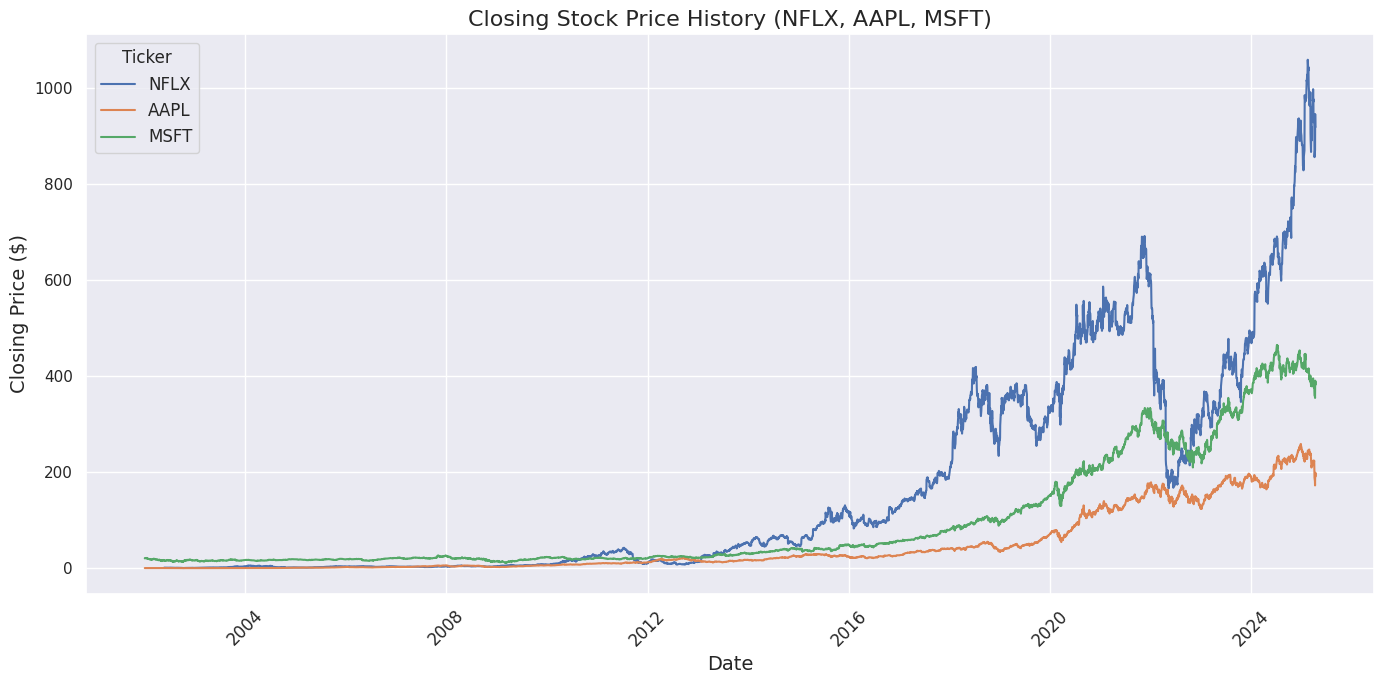

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported if not already

# Assuming 'all_data' DataFrame is loaded and preprocessed as before

plt.figure(figsize=(14, 7))

# Get the unique tickers from the DataFrame
tickers = all_data['Ticker'].unique()

# Loop through each ticker and plot its closing price
for ticker in tickers:
    # Filter data for the current ticker
    ticker_data = all_data[all_data['Ticker'] == ticker]
    # Sort by date to ensure lines connect correctly
    ticker_data = ticker_data.sort_values('Date')
    # Plot Date vs Close for the current ticker, label the line with the ticker symbol
    plt.plot(ticker_data['Date'], ticker_data['Close'], label=ticker)

# Update title and labels for clarity
plt.title('Closing Stock Price History (NFLX, AAPL, MSFT)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Closing Price ($)', fontsize=14) # More specific label

# Add legend to identify the lines
plt.legend(title='Ticker', fontsize=12) # Add a title to the legend

plt.grid(True)
# plt.axis(True) is usually implied when plotting data, grid is more useful
plt.xticks(fontsize=12, rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust plot to prevent labels overlapping
plt.show()

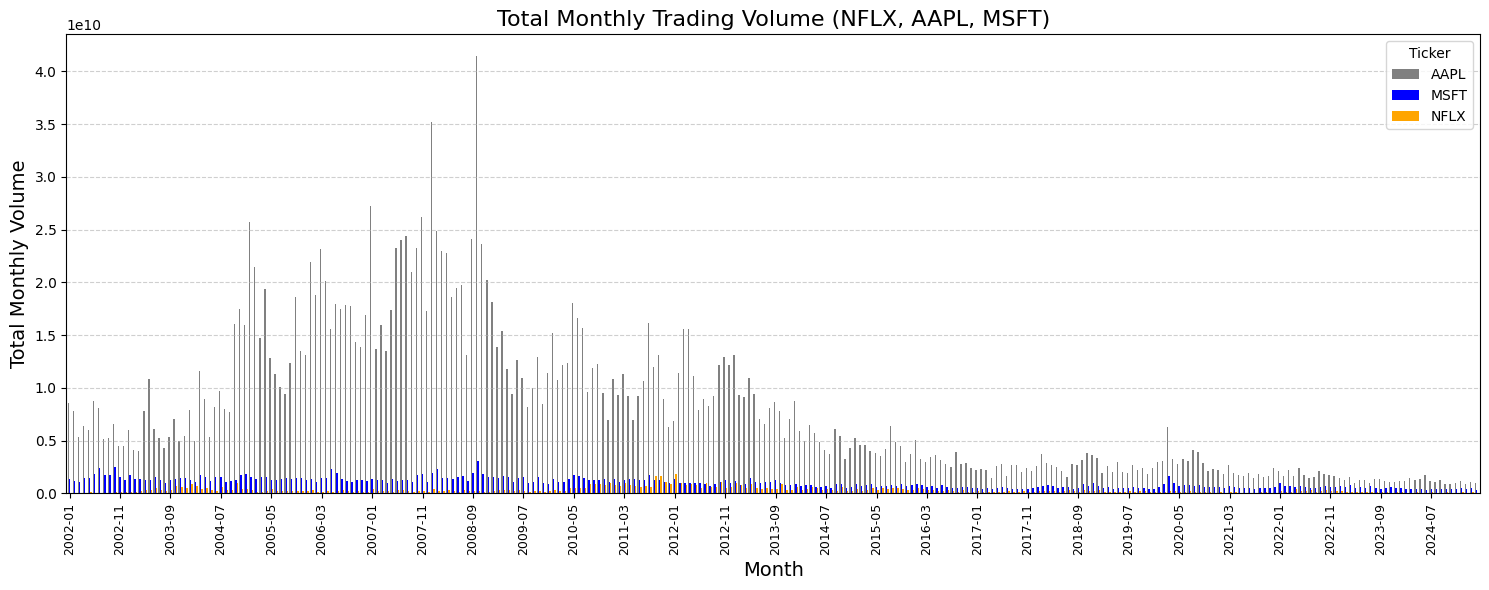

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker # For formatting ticks

# Assuming 'all_data' DataFrame is loaded and preprocessed

# --- Aggregate Data Monthly ---
df_agg = all_data.copy()
df_agg['Date'] = pd.to_datetime(df_agg['Date'])
df_agg = df_agg.set_index('Date')

# Group by Ticker, resample to Month End ('ME'), sum Volume, then make Tickers columns
try:
    monthly_volume = df_agg.groupby('Ticker')['Volume'].resample('ME').sum().unstack(level='Ticker')
    # Fill potential NaN values resulting from resampling (if a stock had no volume in a month)
    monthly_volume = monthly_volume.fillna(0)
except Exception as e:
    print(f"Error during resampling/unstacking: {e}")
    # Handle error or exit if aggregation fails

if 'monthly_volume' in locals() and not monthly_volume.empty:
    # --- Plotting Aggregated Bars ---
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(15, 6), facecolor='white', edgecolor='black')

    # Define colors
    colors = {'NFLX': '#FFA500', 'AAPL': '#808080', 'MSFT': '#0000FF'}

    # Plot grouped bar chart
    monthly_volume.plot(kind='bar', ax=ax, color=[colors.get(c, 'black') for c in monthly_volume.columns], width=0.8)

    # Customize the plot
    ax.set_title('Total Monthly Trading Volume (NFLX, AAPL, MSFT)', fontsize=16)
    ax.set_xlabel('Month', fontsize=14)
    ax.set_ylabel('Total Monthly Volume', fontsize=14)

    # Axis and tick settings - Improve readability for many bars
    # Format x-axis labels as YYYY-MM
    ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_volume.index])

    # Reduce the number of visible x-ticks to prevent overlap
    # Show approximately 20-30 ticks across the range
    num_ticks = min(30, len(monthly_volume.index))
    tick_locator = mticker.MaxNLocator(nbins=num_ticks, integer=True)
    ax.xaxis.set_major_locator(tick_locator)

    ax.tick_params(axis='x', rotation=90, labelsize=9) # Rotate labels
    ax.tick_params(axis='y', labelsize=10)

    ax.legend(title='Ticker', fontsize=10)

    # Grid settings
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.set_facecolor('white')

    # Adjust layout
    plt.tight_layout()
    plt.show()
else:
    print("Could not generate monthly volume data for plotting.")

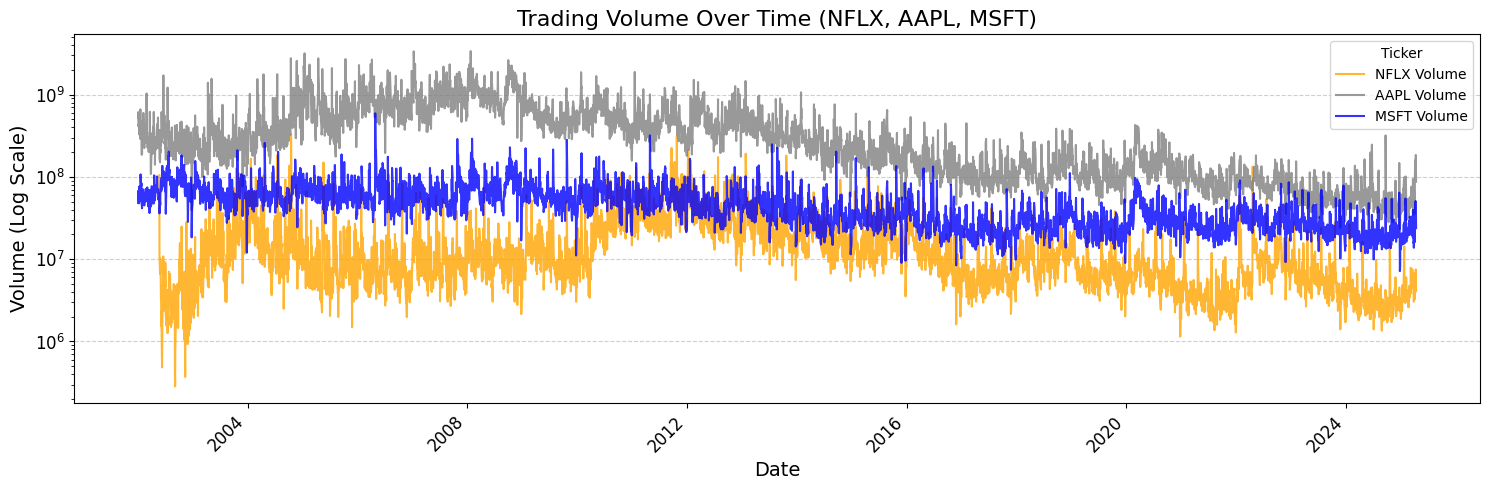

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'all_data' DataFrame is loaded and preprocessed

# Reset style to default first
plt.style.use('default')

# Create the figure with explicit white background
plt.figure(figsize=(15, 5), facecolor='white', edgecolor='black')

# Define colors for the tickers (choose any colors you like)
# Using hex codes for Orange (NFLX), Grey (AAPL), Blue (MSFT)
colors = {'NFLX': '#FFA500', 'AAPL': '#808080', 'MSFT': '#0000FF'}

# Get unique tickers
tickers = all_data['Ticker'].unique()

# Loop through each ticker and plot its volume
for ticker in tickers:
    ticker_data = all_data[all_data['Ticker'] == ticker].sort_values('Date')
    plt.plot(ticker_data['Date'], ticker_data['Volume'],
             label=f"{ticker} Volume",        # Clear label for the legend
             color=colors.get(ticker, 'black'), # Use defined color or default black
             linewidth=1.5,                   # Adjust line width
             alpha=0.8)                       # Adjust transparency

# Customize the plot
plt.title('Trading Volume Over Time (NFLX, AAPL, MSFT)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Volume', fontsize=14)

# Consider using a logarithmic scale for volume due to potentially large variations
plt.yscale('log')
plt.ylabel('Volume (Log Scale)', fontsize=14) # Update label if using log scale

# Axis and tick settings
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12)

# Add legend to identify the lines
plt.legend(title='Ticker', fontsize=10)

# Grid settings (apply to the y-axis, optionally x-axis too)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
# plt.grid(True, axis='x', linestyle=':', alpha=0.4) # Optional x-axis grid

# Ensure white background for the axes
ax = plt.gca()
ax.set_facecolor('white')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

In [ ]:
# Assuming 'all_data' DataFrame is loaded and contains 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume' columns

def remove_outliers_per_ticker(df, features=['Open', 'High', 'Low', 'Close', 'Volume'], contamination=0.01, random_state=42):
    """
    Detect and remove outliers for each ticker separately using Isolation Forest.

    Args:
        df (pd.DataFrame): Input DataFrame with multi-ticker data, must include a 'Ticker' column.
        features (list): List of column names to use for outlier detection.
        contamination (float or 'auto'): The expected proportion of outliers in the data.
        random_state (int): Random seed for reproducibility.

    Returns:
        pd.DataFrame: DataFrame with outliers removed, processed per ticker.
    """
    if df.empty:
        print("Input DataFrame is empty.")
        return df

    if 'Ticker' not in df.columns:
        raise ValueError("Input DataFrame must have a 'Ticker' column.")

    unique_tickers = df['Ticker'].unique()
    cleaned_data_list = []
    original_total_rows = len(df)

    print(f"Starting outlier removal for tickers: {list(unique_tickers)}...")

    for ticker in unique_tickers:
        # Get data for the current ticker and make a copy to avoid modifying slices
        ticker_data = df[df['Ticker'] == ticker].copy()
        original_count = len(ticker_data)
        print(f"\nProcessing {ticker}: Original rows = {original_count}")

        # Ensure there's enough data to fit the model and features exist
        if original_count < 5: # Need a minimum number of samples
             print(f"Skipping {ticker}: Insufficient data points ({original_count}).")
             cleaned_data_list.append(ticker_data) # Keep the original small dataset
             continue

        # Check if all feature columns exist for this ticker's data
        if not all(f in ticker_data.columns for f in features):
            missing_cols = [f for f in features if f not in ticker_data.columns]
            print(f"Skipping {ticker}: Missing feature columns: {missing_cols}.")
            cleaned_data_list.append(ticker_data) # Keep original data if features missing
            continue

        # Select features and drop rows with NaNs in these columns *before* fitting
        ticker_features = ticker_data[features].dropna()

        if ticker_features.empty or len(ticker_features) < 2:
            print(f"Skipping {ticker}: Not enough valid feature data after dropping NaNs.")
            cleaned_data_list.append(ticker_data) # Keep original data
            continue

        # Initialize and fit Isolation Forest
        iso_forest = IsolationForest(contamination=contamination, random_state=random_state, n_estimators=100) # n_estimators is often defaulted/tuned
        try:
            # Fit on the rows *without* NaNs in the feature columns
            outliers = iso_forest.fit_predict(ticker_features) # Returns 1 for inliers, -1 for outliers

            # Get the original indices of the inliers from the 'ticker_features' DataFrame
            inlier_indices = ticker_features.index[outliers == 1]

            # Filter the original 'ticker_data' using these indices
            ticker_data_cleaned = ticker_data.loc[inlier_indices]

            removed_count = original_count - len(ticker_data_cleaned)
            print(f"Finished {ticker}: Removed {removed_count} outliers. Kept {len(ticker_data_cleaned)} rows.")
            cleaned_data_list.append(ticker_data_cleaned)

        except ValueError as e:
             print(f"Error processing {ticker} with Isolation Forest: {e}. Keeping original data for this ticker.")
             cleaned_data_list.append(ticker_data) # Keep original on error

    if not cleaned_data_list:
        print("Warning: No data remaining after attempting outlier removal.")
        return pd.DataFrame(columns=df.columns) # Return empty DataFrame with original columns

    # Combine the cleaned data for all tickers
    final_cleaned_data = pd.concat(cleaned_data_list, ignore_index=True)

    print("\n--- Outlier Removal Summary ---")
    print(f"Original total rows: {original_total_rows}")
    print(f"Total rows after removal: {len(final_cleaned_data)}")
    print(f"Total outliers removed: {original_total_rows - len(final_cleaned_data)}")

    return final_cleaned_data

# --- How to use it ---

# Make sure 'all_data' is your DataFrame with data for NFLX, AAPL, MSFT

print(f"Original data shape: {all_data.shape}")

# Apply the updated function
# Note: contamination=0.01 means assuming 1% of data points per stock are outliers. Adjust if needed.
all_data_cleaned = remove_outliers_per_ticker(all_data.copy(), contamination=0.01, random_state=42) # Pass a copy

# Display the shape of the cleaned data
print(f"Cleaned data shape: {all_data_cleaned.shape}")

# You can now use 'all_data_cleaned' for subsequent analysis or plotting
# For example, to overwrite the original variable (optional):
# all_data = all_data_cleaned

Original data shape: (17476, 7)
Starting outlier removal for tickers: ['NFLX', 'AAPL', 'MSFT']...

Processing NFLX: Original rows = 5760
Finished NFLX: Removed 58 outliers. Kept 5702 rows.

Processing AAPL: Original rows = 5858
Finished AAPL: Removed 59 outliers. Kept 5799 rows.

Processing MSFT: Original rows = 5858
Finished MSFT: Removed 59 outliers. Kept 5799 rows.

--- Outlier Removal Summary ---
Original total rows: 17476
Total rows after removal: 17300
Total outliers removed: 176
Cleaned data shape: (17300, 7)


In [ ]:
import pandas as pd
# Assuming 'all_data_cleaned' is your DataFrame after potential outlier removal
# If you didn't perform outlier removal, use 'all_data' instead.
# Let's assume 'input_df' holds the data you want to add features to.

# Example: Use the cleaned data if it exists, otherwise use the original all_data
if 'all_data_cleaned' in locals() and isinstance(all_data_cleaned, pd.DataFrame):
    input_df = all_data_cleaned.copy()
    print("Using 'all_data_cleaned' for feature engineering.")
elif 'all_data' in locals() and isinstance(all_data, pd.DataFrame):
    input_df = all_data.copy()
    print("Using 'all_data' for feature engineering (outlier removal not performed or result unavailable).")
else:
    raise ValueError("Neither 'all_data_cleaned' nor 'all_data' DataFrame found.")


def create_features_per_ticker(df):
    """
    Create technical indicators and statistical features for each ticker separately.

    Args:
        df (pd.DataFrame): Input DataFrame with multi-ticker data. Must contain
                           'Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume'.

    Returns:
        pd.DataFrame: DataFrame with added features, processed per ticker.
                      Rows with NA values generated during feature creation are dropped.
    """
    if df.empty:
        print("Input DataFrame is empty.")
        return df
    if 'Ticker' not in df.columns:
        raise ValueError("Input DataFrame must have a 'Ticker' column.")

    # CRITICAL: Sort data by Ticker and Date to ensure correct calculations
    print("Sorting data by Ticker and Date...")
    df = df.sort_values(by=['Ticker', 'Date'])

    print("Calculating features per ticker...")

    # Price movements
    # Price_Range is row-wise, doesn't strictly need groupby but harmless here
    df['Price_Range'] = df['High'] - df['Low']
    # Daily_Return needs groupby
    df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

    # Moving averages - Use transform for direct alignment with original index
    df['MA_5'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    df['MA_10'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=10, min_periods=1).mean())
    df['MA_20'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=20, min_periods=1).mean())

    # Momentum indicators - Use diff within groups
    df['Momentum_5'] = df.groupby('Ticker')['Close'].diff(5)
    df['Momentum_10'] = df.groupby('Ticker')['Close'].diff(10)

    # Volatility - Use transform for direct alignment
    df['Volatility_5'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=5, min_periods=1).std())
    df['Volatility_10'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=10, min_periods=1).std())

    # --- Relative Strength Index (RSI) ---
    def calculate_rsi(series, window=14):
        """Helper function to calculate RSI for a given series."""
        delta = series.diff()
        # Make gains and losses Series nonnegative
        gain = delta.where(delta > 0, 0).fillna(0)
        loss = -delta.where(delta < 0, 0).fillna(0)

        # Calculate EMA for gain and loss - More common for RSI than SMA
        # Using Simple Moving Average (SMA) as per original code:
        avg_gain = gain.rolling(window=window, min_periods=1).mean()
        avg_loss = loss.rolling(window=window, min_periods=1).mean()

        # Calculate RS
        rs = avg_gain / avg_loss.replace(0, 1e-9) # Avoid division by zero

        # Calculate RSI
        rsi = 100 - (100 / (1 + rs))
        return rsi

    # Apply RSI calculation per group using transform
    df['RSI'] = df.groupby('Ticker')['Close'].transform(lambda x: calculate_rsi(x, window=14))

    # --- Final Cleanup ---
    print("Dropping rows with NA values introduced by feature calculations...")
    original_rows = len(df)
    df = df.dropna()
    final_rows = len(df)
    print(f"Dropped {original_rows - final_rows} rows containing NA.")

    print("Feature engineering complete.")
    return df

# --- Apply the function ---
# Assuming 'input_df' is the DataFrame prepared above (e.g., all_data_cleaned.copy())
data_with_features = create_features_per_ticker(input_df)

# Display results
print(f"\nDataset shape after feature engineering: {data_with_features.shape}")
print("Tail of the dataset with features:")

# Import display if needed (e.g., outside Jupyter)
try:
    from IPython.display import display
    display(data_with_features.tail())
except ImportError:
    print(data_with_features.tail())

# Optional: Assign to a new variable or overwrite
# all_data_featured = data_with_features

Using 'all_data_cleaned' for feature engineering.
Sorting data by Ticker and Date...
Calculating features per ticker...
Dropping rows with NA values introduced by feature calculations...
Dropped 30 rows containing NA.
Feature engineering complete.

Dataset shape after feature engineering: (17270, 17)
Tail of the dataset with features:


Price,Date,Open,High,Low,Close,Volume,Ticker,Price_Range,Daily_Return,MA_5,MA_10,MA_20,Momentum_5,Momentum_10,Volatility_5,Volatility_10,RSI
5697,2025-04-01,927.500000,932.289978,911.500000,928.380005,3520000,NFLX,20.789978,0.011307,887.403992,866.665997,880.862994,80.119995,49.190002,37.113294,35.067762,60.217251
5698,2025-04-07,827.849976,906.739990,821.099976,867.830017,6656800,NFLX,85.640015,-0.065221,892.495996,865.948999,879.152496,25.460022,-7.169983,30.557419,34.951538,46.018041
5699,2025-04-08,912.440002,922.419983,857.700012,870.400024,5625400,NFLX,64.719971,0.002961,894.956006,869.220001,877.219998,12.300049,32.710022,27.431327,33.514071,47.726406
5700,2025-04-10,931.940002,941.239990,894.000000,921.169983,5129800,NFLX,47.239990,0.058329,901.156006,877.308002,877.705997,31.000000,80.880005,29.504141,35.459575,56.927249
5701,2025-04-11,920.000000,944.859985,906.679993,918.289978,4070300,NFLX,38.179993,-0.003126,901.214001,886.296997,878.242996,0.289978,89.889954,29.545784,32.991489,56.871220


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Assuming 'data_with_features' is your DataFrame after feature engineering
# Example: Use the featured data if it exists
if 'data_with_features' in locals() and isinstance(data_with_features, pd.DataFrame):
    input_df_norm = data_with_features.copy()
    print("Using 'data_with_features' for normalization.")
elif 'all_data_cleaned' in locals() and isinstance(all_data_cleaned, pd.DataFrame):
     input_df_norm = all_data_cleaned.copy()
     print("Warning: Using data before feature engineering for normalization. Features might be missing.")
elif 'all_data' in locals() and isinstance(all_data, pd.DataFrame):
     input_df_norm = all_data.copy()
     print("Warning: Using original data before feature engineering/outlier removal for normalization.")
else:
    raise ValueError("No suitable DataFrame found ('data_with_features', 'all_data_cleaned', or 'all_data').")


def normalize_data_per_ticker(df):
    """
    Normalize features for each ticker separately using MinMaxScaler.
    Adds new columns with '_scaled' suffix.
    Optionally scales 'Close' price separately.

    Args:
        df (pd.DataFrame): Input DataFrame with multi-ticker data.

    Returns:
        tuple: (pd.DataFrame with scaled columns,
                dict of feature scalers {ticker: scaler},
                dict of close price scalers {ticker: scaler})
    """
    if df.empty:
        print("Input DataFrame is empty.")
        return df, {}, {}
    if 'Ticker' not in df.columns:
        raise ValueError("Input DataFrame must have a 'Ticker' column.")

    # Define features to scale (EXCLUDING 'Close' if it's the target)
    # Add any other engineered features you want scaled
    features_to_scale = [
        'Open', 'High', 'Low', 'Volume', 'Price_Range', 'Daily_Return',
        'MA_5', 'MA_10', 'MA_20', 'Momentum_5', 'Momentum_10',
        'Volatility_5', 'Volatility_10', 'RSI'
    ]
    # Filter list to include only columns present in the DataFrame
    features_to_scale = [f for f in features_to_scale if f in df.columns]

    if not features_to_scale:
        print("No features identified for scaling.")
        # Still attempt to scale 'Close' if present
    else:
         print(f"Features to scale per ticker: {features_to_scale}")

    # Dictionaries to store scalers for potential inverse transformation
    feature_scalers_dict = {}
    close_scalers_dict = {}
    scaled_data_list = []

    # Sort for consistency (though scaling doesn't strictly depend on order)
    df = df.sort_values(by=['Ticker', 'Date'])

    print("Starting normalization process...")

    for ticker in df['Ticker'].unique():
        ticker_data = df[df['Ticker'] == ticker].copy()
        print(f"Processing {ticker}...")

        # --- Scale Features ---
        if features_to_scale:
            # Check for NaNs before scaling this ticker's features
            if ticker_data[features_to_scale].isnull().any().any():
                 print(f"  Warning: NaN values detected in features for {ticker} before scaling. Check prior steps.")
                 # Consider ticker_data[features_to_scale] = ticker_data[features_to_scale].fillna(method='ffill').fillna(method='bfill')
                 # Or simply let MinMaxScaler handle potential errors column-wise if needed

            try:
                feature_scaler = MinMaxScaler(feature_range=(0, 1))
                scaled_feature_names = [f"{f}_scaled" for f in features_to_scale]
                # Fit and transform features for this ticker
                scaled_values = feature_scaler.fit_transform(ticker_data[features_to_scale])
                # Assign scaled values to new columns
                ticker_data[scaled_feature_names] = scaled_values
                feature_scalers_dict[ticker] = feature_scaler # Store the scaler
                print(f"  Successfully scaled features for {ticker}.")
            except Exception as e:
                print(f"  Error scaling features for {ticker}: {e}. Skipping feature scaling.")

        # --- Scale 'Close' Price Separately ---
        if 'Close' in ticker_data.columns and not ticker_data['Close'].isnull().all():
            try:
                close_scaler = MinMaxScaler(feature_range=(0, 1))
                # Fit and transform the 'Close' column
                ticker_data['Close_scaled'] = close_scaler.fit_transform(ticker_data[['Close']])
                close_scalers_dict[ticker] = close_scaler # Store the scaler
                print(f"  Successfully scaled 'Close' price for {ticker}.")
            except Exception as e:
                print(f"  Error scaling 'Close' price for {ticker}: {e}. Skipping 'Close' scaling.")
        else:
             print(f"  'Close' column not found or all NaN for {ticker}. Skipping 'Close' scaling.")


        scaled_data_list.append(ticker_data)

    # Combine processed data
    if not scaled_data_list:
        print("Warning: No data was processed.")
        return pd.DataFrame(columns=df.columns), {}, {}

    final_data = pd.concat(scaled_data_list, ignore_index=True)
    print("\nNormalization complete for all tickers.")

    return final_data, feature_scalers_dict, close_scalers_dict

# --- Apply the function ---
# Use the DataFrame that has the features created ('data_with_features')
data_normalized, feature_scalers, close_scalers = normalize_data_per_ticker(input_df_norm) # Use the df selected earlier

# Display results
print("\nData after normalization (showing head):")
try:
    from IPython.display import display
    display(data_normalized.head())
except ImportError:
    print(data_normalized.head())

print(f"\nNormalized data shape: {data_normalized.shape}")

# You can access the scalers later if needed, e.g.:
# aapl_feature_scaler = feature_scalers.get('AAPL')
# nflx_close_scaler = close_scalers.get('NFLX')
# if nflx_close_scaler:
#     original_nflx_close = nflx_close_scaler.inverse_transform(some_scaled_nflx_close_data)

# Optional: Overwrite variable if desired
# data_final = data_normalized

Using 'data_with_features' for normalization.
Features to scale per ticker: ['Open', 'High', 'Low', 'Volume', 'Price_Range', 'Daily_Return', 'MA_5', 'MA_10', 'MA_20', 'Momentum_5', 'Momentum_10', 'Volatility_5', 'Volatility_10', 'RSI']
Starting normalization process...
Processing AAPL...
  Successfully scaled features for AAPL.
  Successfully scaled 'Close' price for AAPL.
Processing MSFT...
  Successfully scaled features for MSFT.
  Successfully scaled 'Close' price for MSFT.
Processing NFLX...
  Successfully scaled features for NFLX.
  Successfully scaled 'Close' price for NFLX.

Normalization complete for all tickers.

Data after normalization (showing head):


Price,Date,Open,High,Low,Close,Volume,Ticker,Price_Range,Daily_Return,MA_5,MA_10,MA_20,Momentum_5,Momentum_10,Volatility_5,Volatility_10,RSI,Open_scaled,High_scaled,Low_scaled,Volume_scaled,Price_Range_scaled,Daily_Return_scaled,MA_5_scaled,MA_10_scaled,MA_20_scaled,Momentum_5_scaled,Momentum_10_scaled,Volatility_5_scaled,Volatility_10_scaled,RSI_scaled,Close_scaled
0,2002-01-16,0.322152,0.322152,0.308459,0.312672,566893600,AAPL,0.013693,-0.042397,0.318721,0.331541,0.333273,-0.013091,-0.037918,0.005051,0.016207,22.609060,0.000538,0.000520,0.000502,0.162096,0.000388,0.411441,0.000509,0.000563,0.000544,0.706241,0.675681,0.000218,0.000703,0.205199,0.000487
1,2002-01-17,0.330428,0.342164,0.329074,0.338252,660576000,AAPL,0.013090,0.081812,0.322483,0.329886,0.333688,0.018809,-0.016551,0.010152,0.014301,43.492617,0.000573,0.000605,0.000590,0.190069,0.000367,0.785022,0.000525,0.000556,0.000546,0.706685,0.675963,0.000471,0.000607,0.425758,0.000595
2,2002-01-18,0.331029,0.340057,0.330428,0.333588,338811200,AAPL,0.009629,-0.013791,0.325854,0.327599,0.333680,0.016852,-0.022871,0.010556,0.011035,41.452793,0.000576,0.000596,0.000596,0.093989,0.000246,0.497481,0.000540,0.000546,0.000546,0.706658,0.675879,0.000491,0.000444,0.404214,0.000575
3,2002-01-22,0.335093,0.336597,0.328321,0.328321,327314400,AAPL,0.008275,-0.015787,0.327870,0.325974,0.333297,0.010081,-0.016251,0.009663,0.009321,39.368261,0.000593,0.000581,0.000587,0.090556,0.000199,0.491476,0.000549,0.000539,0.000544,0.706564,0.675966,0.000446,0.000358,0.382199,0.000553
4,2002-01-23,0.328020,0.346679,0.324861,0.346377,443279200,AAPL,0.021818,0.054994,0.331842,0.326591,0.334169,0.019861,0.006169,0.012602,0.010498,48.284375,0.000563,0.000624,0.000572,0.125184,0.000671,0.704363,0.000566,0.000542,0.000548,0.706700,0.676262,0.000592,0.000417,0.476365,0.000629



Normalized data shape: (17270, 32)


In [ ]:
import numpy as np
import pandas as pd

# --- Select Input DataFrame ---
# Assume 'data_normalized' is your DataFrame after normalization,
# containing scaled features (e.g., 'Open_scaled', 'Volume_scaled', 'RSI_scaled')
# and the scaled target ('Close_scaled').

if 'data_normalized' in locals() and isinstance(data_normalized, pd.DataFrame):
    input_df_seq = data_normalized
    print("Using 'data_normalized' for sequence creation.")
# Add fallbacks if needed, with warnings
elif 'data_with_features' in locals() and isinstance(data_with_features, pd.DataFrame):
    input_df_seq = data_with_features
    print("\nWarning: Using 'data_with_features' (potentially unscaled) for sequence creation. Ensure features are scaled appropriately for your model.")
elif 'all_data_cleaned' in locals() and isinstance(all_data_cleaned, pd.DataFrame):
     input_df_seq = all_data_cleaned
     print("\nWarning: Using 'all_data_cleaned' (unscaled, no features) for sequence creation. Feature columns may be missing.")
else:
    raise ValueError("Suitable input DataFrame ('data_normalized', 'data_with_features', etc.) not found.")

# --- Updated Sequence Creation Function ---
def create_sequences_per_ticker(df, seq_length, target_col='Close_scaled', feature_suffix='_scaled'):
    """
    Create input sequences (X) and corresponding targets (y) for time series prediction,
    processing each ticker separately.

    Args:
        df (pd.DataFrame): Input DataFrame with scaled features and target.
                           Must include a 'Ticker' column.
        seq_length (int): The number of time steps to look back (sequence length).
        target_col (str): The name of the column containing the target variable (scaled).
        feature_suffix (str): The suffix identifying the scaled feature columns to use.

    Returns:
        tuple: (np.array of sequences (X), np.array of targets (y))
    """
    if df.empty:
        print("Input DataFrame is empty.")
        return np.array([]), np.array([])
    if 'Ticker' not in df.columns:
        raise ValueError("Input DataFrame must have a 'Ticker' column.")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")

    # Identify scaled feature columns (e.g., ending with '_scaled')
    # Important: Exclude the target column from this list initially
    feature_columns = [col for col in df.columns if col.endswith(feature_suffix) and col != target_col]

    # Option: Decide if the target variable itself should be an input feature
    include_target_in_features = True # Common practice for time series prediction
    if include_target_in_features and target_col in df.columns:
         if target_col not in feature_columns: # Add if not already included by suffix match
              feature_columns.append(target_col)
         print(f"Including target '{target_col}' as an input feature.")
         # Optional: Ensure a consistent order, e.g., target last
         feature_columns.sort(key=lambda x: (x == target_col, x))


    if not feature_columns:
        raise ValueError(f"No feature columns found ending with '{feature_suffix}'. Check normalization step.")

    print(f"Using features for sequences: {feature_columns}")
    print(f"Using target column: {target_col}")

    X_list, y_list = [], []
    unique_tickers = df['Ticker'].unique()

    # Sort data by Ticker and Date REQUIRED for correct sequence generation within groups
    df = df.sort_values(by=['Ticker', 'Date'])

    print(f"Creating sequences with length {seq_length} for tickers: {list(unique_tickers)}...")

    for ticker in unique_tickers:
        # Get data for the current ticker
        ticker_data = df[df['Ticker'] == ticker]
        ticker_len = len(ticker_data)
        #print(f"  Processing {ticker}: {ticker_len} rows") # Verbose

        if ticker_len <= seq_length:
            print(f"  Skipping {ticker}: Not enough data points ({ticker_len}) for sequence length {seq_length}.")
            continue

        # Extract the relevant feature and target columns as NumPy arrays
        ticker_features_np = ticker_data[feature_columns].values
        ticker_target_np = ticker_data[target_col].values

        # Create sequences for this ticker
        for i in range(ticker_len - seq_length):
            X_list.append(ticker_features_np[i : i + seq_length]) # Input sequence
            y_list.append(ticker_target_np[i + seq_length])     # Target value (next step)

    if not X_list:
        print("Warning: No sequences were created. Check data length per ticker and sequence length.")
        return np.array([]), np.array([])

    print(f"Sequence creation complete. Generated {len(X_list)} sequences.")
    return np.array(X_list), np.array(y_list)


# --- Data Augmentation Function (remains the same logic) ---
def jitter(X, noise_factor=0.005): # Adjusted noise factor for [0,1] scaled data
    """
    Add small random Gaussian noise to sequences for data augmentation.

    Args:
        X (np.array): Input sequences.
        noise_factor (float): Standard deviation of the Gaussian noise.

    Returns:
        np.array: Sequences with added noise.
    """
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=X.shape)
    return X + noise

# --- Parameters ---
SEQ_LENGTH = 10  # Number of days to look back
# TEST_SIZE = 0.2 # Note: This parameter is for splitting, not sequence creation itself.
                 # Splitting needs careful handling for time series (see note below).

# --- Create Sequences ---
# Use the selected DataFrame (input_df_seq)
X, y = create_sequences_per_ticker(input_df_seq.copy(), # Pass a copy
                                   seq_length=SEQ_LENGTH,
                                   target_col='Close_scaled',
                                   feature_suffix='_scaled')

print(f"\nShape after initial sequence creation: X = {X.shape}, y = {y.shape}")

# --- Data Augmentation and Final Preparation ---
if X.size > 0: # Only proceed if sequences were created
    print("\nApplying jittering for data augmentation...")
    X_augmented = jitter(X, noise_factor=0.005)

    # Combine original and augmented data
    X_final = np.concatenate([X, X_augmented], axis=0)
    y_final = np.concatenate([y, y], axis=0) # Targets are duplicated for augmented data

    print(f"Shape after augmentation: X = {X_final.shape}, y = {y_final.shape}")

    # --- Shuffle the combined dataset (IMPORTANT for training batches) ---
    print("Shuffling the combined dataset...")
    indices = np.arange(X_final.shape[0])
    np.random.seed(42) # for reproducibility
    np.random.shuffle(indices)

    X_final = X_final[indices]
    y_final = y_final[indices]

    print(f"Final dataset shape after augmentation and shuffling: X = {X_final.shape}, y = {y_final.shape}")

else:
    print("\nSkipping augmentation and shuffling as no sequences were created.")
    X_final, y_final = X, y # Keep empty arrays if no sequences


# --- IMPORTANT NOTE ON TRAIN/TEST SPLIT ---
# A standard random split (like train_test_split from sklearn) on X_final and y_final
# is generally INCORRECT for time series forecasting. It mixes past and future data
# and breaks temporal dependencies across different tickers.
#
# A proper split should typically be done *before* augmentation and shuffling:
# 1. For each ticker, divide its sequences chronologically (e.g., first 80% train, last 20% test).
# 2. Concatenate all training sequences into one training set (X_train_all, y_train_all).
# 3. Concatenate all test sequences into one test set (X_test_all, y_test_all).
# 4. Apply augmentation *only* to the training set (X_train_all).
# 5. Shuffle the augmented training set before feeding it to the model.
# This maintains the temporal order for evaluation on the test set.
# Implementing this split requires additional logic before the augmentation step shown here.

Using 'data_normalized' for sequence creation.
Including target 'Close_scaled' as an input feature.
Using features for sequences: ['Daily_Return_scaled', 'High_scaled', 'Low_scaled', 'MA_10_scaled', 'MA_20_scaled', 'MA_5_scaled', 'Momentum_10_scaled', 'Momentum_5_scaled', 'Open_scaled', 'Price_Range_scaled', 'RSI_scaled', 'Volatility_10_scaled', 'Volatility_5_scaled', 'Volume_scaled', 'Close_scaled']
Using target column: Close_scaled
Creating sequences with length 10 for tickers: ['AAPL', 'MSFT', 'NFLX']...
Sequence creation complete. Generated 17240 sequences.

Shape after initial sequence creation: X = (17240, 10, 15), y = (17240,)

Applying jittering for data augmentation...
Shape after augmentation: X = (34480, 10, 15), y = (34480,)
Shuffling the combined dataset...
Final dataset shape after augmentation and shuffling: X = (34480, 10, 15), y = (34480,)


In [ ]:
import numpy as np
import pandas as pd

# --- Select Input DataFrame ---
# Assume 'data_normalized' is your DataFrame after normalization,
# containing scaled features (e.g., 'Open_scaled', 'Volume_scaled', 'RSI_scaled')
# and the scaled target ('Close_scaled').

if 'data_normalized' in locals() and isinstance(data_normalized, pd.DataFrame):
    input_df_seq = data_normalized
    print("Using 'data_normalized' for sequence creation.")
# Add fallbacks if needed, with warnings
elif 'data_with_features' in locals() and isinstance(data_with_features, pd.DataFrame):
    input_df_seq = data_with_features
    print("\nWarning: Using 'data_with_features' (potentially unscaled) for sequence creation. Ensure features are scaled appropriately for your model.")
elif 'all_data_cleaned' in locals() and isinstance(all_data_cleaned, pd.DataFrame):
    input_df_seq = all_data_cleaned
    print("\nWarning: Using 'all_data_cleaned' (unscaled, no features) for sequence creation. Feature columns may be missing.")
else:
    raise ValueError("Suitable input DataFrame ('data_normalized', 'data_with_features', etc.) not found.")

# --- Updated Sequence Creation Function ---
def create_sequences_per_ticker(df, seq_length, target_col='Close_scaled', feature_suffix='_scaled'):
    """
    Create input sequences (X) and corresponding targets (y) for time series prediction,
    processing each ticker separately.

    Args:
        df (pd.DataFrame): Input DataFrame with scaled features and target.
                                        Must include a 'Ticker' column.
        seq_length (int): The number of time steps to look back (sequence length).
        target_col (str): The name of the column containing the target variable (scaled).
        feature_suffix (str): The suffix identifying the scaled feature columns to use.

    Returns:
        tuple: (np.array of sequences (X), np.array of targets (y))
    """
    if df.empty:
        print("Input DataFrame is empty.")
        return np.array([]), np.array([])
    if 'Ticker' not in df.columns:
        raise ValueError("Input DataFrame must have a 'Ticker' column.")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")

    # Identify scaled feature columns (e.g., ending with '_scaled')
    # Important: Exclude the target column from this list initially
    feature_columns = [col for col in df.columns if col.endswith(feature_suffix) and col != target_col]

    # Option: Decide if the target variable itself should be an input feature
    include_target_in_features = True # Common practice for time series prediction
    if include_target_in_features and target_col in df.columns:
        if target_col not in feature_columns: # Add if not already included by suffix match
            feature_columns.append(target_col)
        print(f"Including target '{target_col}' as an input feature.")
        # Optional: Ensure a consistent order, e.g., target last
        feature_columns.sort(key=lambda x: (x == target_col, x))


    if not feature_columns:
        raise ValueError(f"No feature columns found ending with '{feature_suffix}'. Check normalization step.")

    print(f"Using features for sequences: {feature_columns}")
    print(f"Using target column: {target_col}")

    X_list, y_list = [], []
    unique_tickers = df['Ticker'].unique()

    # Sort data by Ticker and Date REQUIRED for correct sequence generation within groups
    df = df.sort_values(by=['Ticker', 'Date'])

    print(f"Creating sequences with length {seq_length} for tickers: {list(unique_tickers)}...")

    for ticker in unique_tickers:
        # Get data for the current ticker
        ticker_data = df[df['Ticker'] == ticker]
        ticker_len = len(ticker_data)
        #print(f"  Processing {ticker}: {ticker_len} rows") # Verbose

        if ticker_len <= seq_length:
            print(f"  Skipping {ticker}: Not enough data points ({ticker_len}) for sequence length {seq_length}.")
            continue

        # Extract the relevant feature and target columns as NumPy arrays
        ticker_features_np = ticker_data[feature_columns].values
        ticker_target_np = ticker_data[target_col].values

        # Create sequences for this ticker
        for i in range(ticker_len - seq_length):
            X_list.append(ticker_features_np[i : i + seq_length]) # Input sequence
            y_list.append(ticker_target_np[i + seq_length])     # Target value (next step)

    if not X_list:
        print("Warning: No sequences were created. Check data length per ticker and sequence length.")
        return np.array([]), np.array([])

    print(f"Sequence creation complete. Generated {len(X_list)} sequences.")
    return np.array(X_list), np.array(y_list)


# --- Data Augmentation Function (remains the same logic) ---
def jitter(X, noise_factor=0.005): # Adjusted noise factor for [0,1] scaled data
    """
    Add small random Gaussian noise to sequences for data augmentation.

    Args:
        X (np.array): Input sequences.
        noise_factor (float): Standard deviation of the Gaussian noise.

    Returns:
        np.array: Sequences with added noise.
    """
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=X.shape)
    return X + noise

# --- Parameters ---
SEQ_LENGTH = 10  # Number of days to look back
TEST_SIZE = 0.2 # Define TEST_SIZE here

# --- Create Sequences ---
# Use the selected DataFrame (input_df_seq)
X, y = create_sequences_per_ticker(input_df_seq.copy(), # Pass a copy
                                     seq_length=SEQ_LENGTH,
                                     target_col='Close_scaled',
                                     feature_suffix='_scaled')

print(f"\nShape after initial sequence creation: X = {X.shape}, y = {y.shape}")

# --- Data Augmentation and Final Preparation ---
if X.size > 0: # Only proceed if sequences were created
    print("\nApplying jittering for data augmentation...")
    X_augmented = jitter(X, noise_factor=0.005)

    # Combine original and augmented data
    X_final = np.concatenate([X, X_augmented], axis=0)
    y_final = np.concatenate([y, y], axis=0) # Targets are duplicated for augmented data

    print(f"Shape after augmentation: X = {X_final.shape}, y = {y_final.shape}")

    # --- Shuffle the combined dataset (IMPORTANT for training batches) ---
    print("Shuffling the combined dataset...")
    indices = np.arange(X_final.shape[0])
    np.random.seed(42) # for reproducibility
    np.random.shuffle(indices)

    X_final = X_final[indices]
    y_final = y_final[indices]

    print(f"Final dataset shape after augmentation and shuffling: X = {X_final.shape}, y = {y_final.shape}")

else:
    print("\nSkipping augmentation and shuffling as no sequences were created.")
    X_final, y_final = X, y # Keep empty arrays if no sequences


# --- IMPORTANT NOTE ON TRAIN/TEST SPLIT ---
# A standard random split (like train_test_split from sklearn) on X_final and y_final
# is generally INCORRECT for time series forecasting. It mixes past and future data
# and breaks temporal dependencies across different tickers.
#
# A proper split should typically be done *before* augmentation and shuffling:
# 1. For each ticker, divide its sequences chronologically (e.g., first 80% train, last 20% test).
# 2. Concatenate all training sequences into one training set (X_train_all, y_train_all).
# 3. Concatenate all test sequences into one test set (X_test_all, y_test_all).
# 4. Apply augmentation *only* to the training set (X_train_all).
# 5. Shuffle the augmented training set before feeding it to the model.
# This maintains the temporal order for evaluation on the test set.
# Implementing this split requires additional logic before the augmentation step shown here.

# Train-test split with time series cross-validation
def train_test_split_time_series(X, y, test_size=0.2):
    """
    Custom time series split that maintains temporal order
    """
    split_idx = int(len(X) * (1 - test_size))

    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return X_train, X_test, y_train, y_test

# Apply the time series split to the FINAL augmented and shuffled data
X_train, X_test, y_train, y_test = train_test_split_time_series(X_final, y_final, TEST_SIZE)

print(f"Training set: X = {X_train.shape}, y = {y_train.shape}")
print(f"Testing set: X = {X_test.shape}, y = {y_test.shape}")

Using 'data_normalized' for sequence creation.
Including target 'Close_scaled' as an input feature.
Using features for sequences: ['Daily_Return_scaled', 'High_scaled', 'Low_scaled', 'MA_10_scaled', 'MA_20_scaled', 'MA_5_scaled', 'Momentum_10_scaled', 'Momentum_5_scaled', 'Open_scaled', 'Price_Range_scaled', 'RSI_scaled', 'Volatility_10_scaled', 'Volatility_5_scaled', 'Volume_scaled', 'Close_scaled']
Using target column: Close_scaled
Creating sequences with length 10 for tickers: ['AAPL', 'MSFT', 'NFLX']...
Sequence creation complete. Generated 17240 sequences.

Shape after initial sequence creation: X = (17240, 10, 15), y = (17240,)

Applying jittering for data augmentation...
Shape after augmentation: X = (34480, 10, 15), y = (34480,)
Shuffling the combined dataset...
Final dataset shape after augmentation and shuffling: X = (34480, 10, 15), y = (34480,)
Training set: X = (27584, 10, 15), y = (27584,)
Testing set: X = (6896, 10, 15), y = (6896,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_lstm_model(input_shape, lstm_units=64, dense_units=32, dropout_rate=0.2, learning_rate=0.001):
    """
    Build and compile LSTM model
    """
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(dropout_rate),
        LSTM(lstm_units//2),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(dense_units, activation='relu'),
        Dense(1)
    ])

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

# Initialize LSTM model
# Check if X_train has the expected number of dimensions
if len(X_train.shape) != 3:
    raise ValueError(f"X_train should have 3 dimensions (samples, time_steps, features), but got shape {X_train.shape}")

input_shape = (SEQ_LENGTH, X_train.shape[2])
lstm_model = build_lstm_model(input_shape)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,369 (134.25 KB)

 Trainable params: 34,177 (133.50 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# XGBoost Model
import xgboost as xgb

def build_xgboost_model(n_estimators=100, max_depth=5, learning_rate=0.1):
    """
    Build XGBoost model
    """
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42
    )
    return model

# Prepare data for XGBoost (flatten sequences)
xgb_X_train = X_train.reshape(X_train.shape[0], -1)
xgb_X_test = X_test.reshape(X_test.shape[0], -1)

# Initialize XGBoost model
xgb_model = build_xgboost_model()

print("XGBoost model initialized.")
print(f"Shape of training data for XGBoost: {xgb_X_train.shape}")
print(f"Shape of testing data for XGBoost: {xgb_X_test.shape}")

XGBoost model initialized.
Shape of training data for XGBoost: (27584, 150)
Shape of testing data for XGBoost: (6896, 150)


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Save in new Keras format
checkpoint = ModelCheckpoint('best_lstm_model.keras', save_best_only=True)

history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

print("LSTM model training started with the following settings:")
print(f"  - Maximum epochs: {100}") # Use the value directly passed
print(f"  - Batch size: {32}")       # Use the value directly passed
print(f"  - Validation split: {0.2:.2f}") # Use the value directly passed
print(f"  - Early stopping patience: {early_stopping.patience}")
print(f"  - Model checkpoint file: {checkpoint.filepath}")

Epoch 1/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - loss: 0.0900 - mae: 0.1965 - val_loss: 0.0023 - val_mae: 0.0368
Epoch 2/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0074 - mae: 0.0648 - val_loss: 0.0019 - val_mae: 0.0339
Epoch 3/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0039 - mae: 0.0460 - val_loss: 5.4783e-04 - val_mae: 0.0175
Epoch 4/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0027 - mae: 0.0376 - val_loss: 4.8147e-04 - val_mae: 0.0181
Epoch 5/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 0.0020 - mae: 0.0319 - val_loss: 6.0008e-04 - val_mae: 0.0149
Epoch 6/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - loss: 0.0016 - mae: 0.0270 - val_loss: 0.0010 - val_mae: 0.0201
Epoch 7/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - loss: 0.0015 - mae: 0.0259 - val_loss: 8.9082e-04 - val_mae: 0.0227
Epoch 8/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0014 - mae: 0.0247 - val_loss: 1.0682e-04 - val_mae: 0.0064
Epoch 9/100


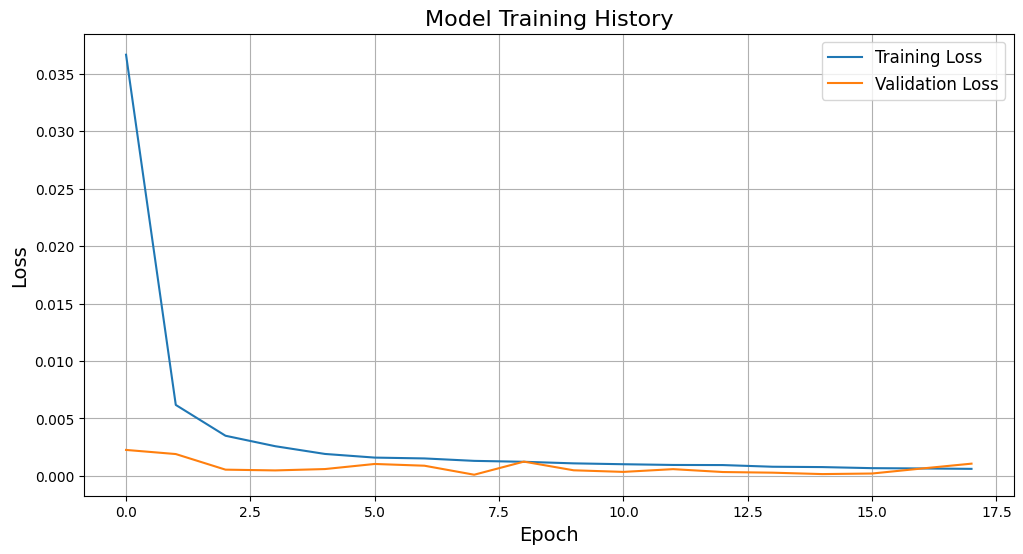

In [ ]:
# Plot training history
def plot_training_history(history):
    """
    Plot training and validation loss
    """
    plt.figure(figsize=(12, 6))

    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title('Model Training History', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.show()

plot_training_history(history)


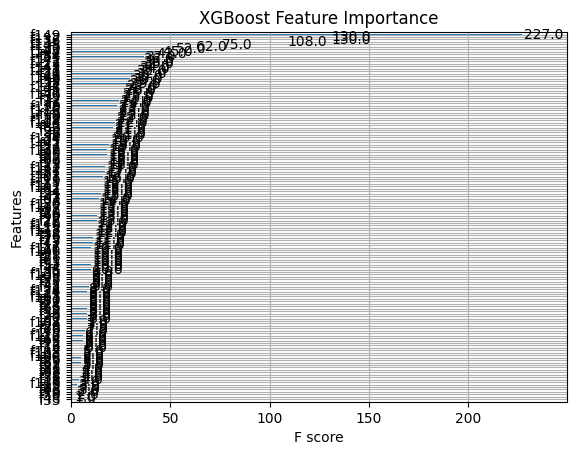

In [ ]:
# Train XGBoost Model
xgb_model.fit(xgb_X_train, y_train)

# Feature importance
xgb.plot_importance(xgb_model)
plt.title('XGBoost Feature Importance')
plt.show()

In [ ]:
# Make predictions
lstm_pred = lstm_model.predict(X_test).flatten()
xgb_pred = xgb_model.predict(xgb_X_test)

# Hybrid prediction (weighted ensemble)
hybrid_pred = 0.4 * lstm_pred + 0.6 * xgb_pred

216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
from IPython.display import display

def evaluate_models(y_true, lstm_pred, xgb_pred, hybrid_pred):
    """
    Evaluate model performance using multiple metrics
    """
    results = []

    def calculate_metrics(y_true, y_pred, model_name):
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        return {
            "Model": model_name,
            "MSE": round(mse, 6),
            "MAE": round(mae, 6),
            "R² Score": round(r2, 4)
        }

    results.append(calculate_metrics(y_true, lstm_pred, "LSTM"))
    results.append(calculate_metrics(y_true, xgb_pred, "XGBoost"))
    results.append(calculate_metrics(y_true, hybrid_pred, "Hybrid"))

    return pd.DataFrame(results)

# Evaluate models
results_df = evaluate_models(y_test, lstm_pred, xgb_pred, hybrid_pred)
print("Model Performance Comparison:")
display(results_df)

Model Performance Comparison:


,Model,MSE,MAE,R² Score
0,LSTM,0.000107,0.006377,0.9983
1,XGBoost,0.000038,0.003092,0.9994
2,Hybrid,0.000048,0.003809,0.9993


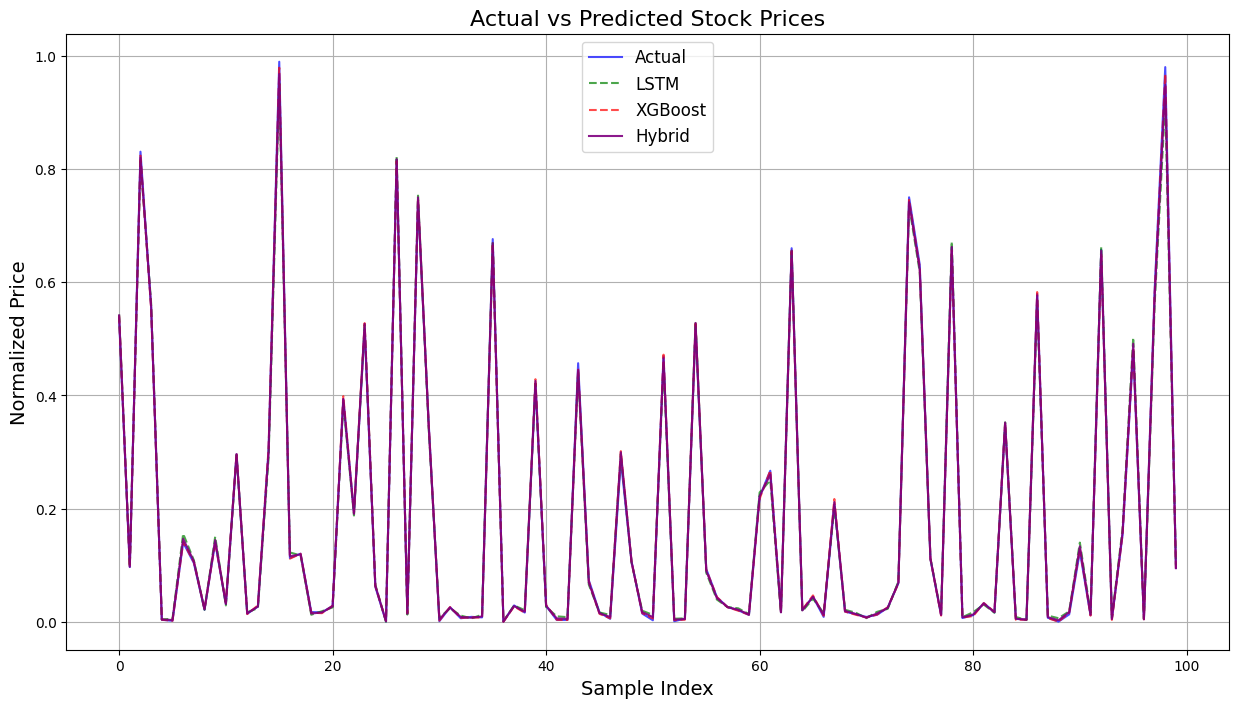

In [ ]:
# Visualize predictions vs actual values
def plot_predictions(y_true, lstm_pred, xgb_pred, hybrid_pred, n_samples=100):
    """
    Plot actual vs predicted values
    """
    plt.figure(figsize=(15, 8))

    # Select a subset for clearer visualization
    idx = np.random.choice(len(y_true), size=min(n_samples, len(y_true)), replace=False)

    plt.plot(y_true[idx], label='Actual', color='blue', alpha=0.7)
    plt.plot(lstm_pred[idx], label='LSTM', color='green', linestyle='--', alpha=0.7)
    plt.plot(xgb_pred[idx], label='XGBoost', color='red', linestyle='--', alpha=0.7)
    plt.plot(hybrid_pred[idx], label='Hybrid', color='purple', linestyle='-', alpha=0.9)

    plt.title('Actual vs Predicted Stock Prices', fontsize=16)
    plt.xlabel('Sample Index', fontsize=14)
    plt.ylabel('Normalized Price', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.show()

plot_predictions(y_test, lstm_pred, xgb_pred, hybrid_pred)

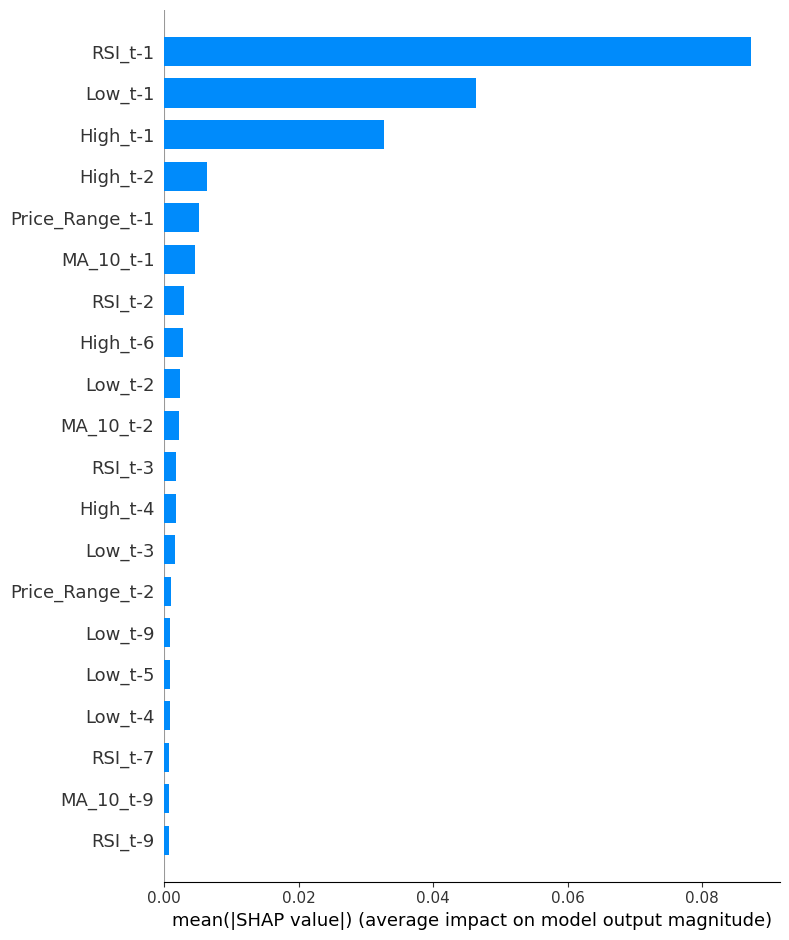

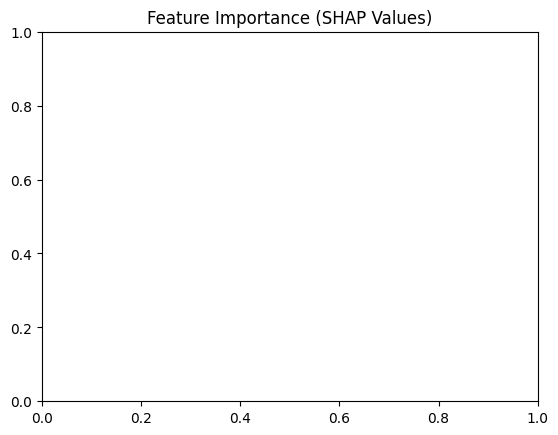

In [ ]:
# SHAP Explainability for XGBoost
import shap
import matplotlib.pyplot as plt

def explain_model(model, X, feature_names):
    """
    Explain model predictions using SHAP values
    """
    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values
    shap_values = explainer.shap_values(X)

    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, feature_names=feature_names, plot_type="bar")
    plt.title('Feature Importance (SHAP Values)')
    plt.show()

    # # Force plot for a single prediction
    # plt.figure(figsize=(12, 6))
    # shap.force_plot(explainer.expected_value, shap_values[0,:], X[0,:], feature_names=feature_names)
    # plt.title('SHAP Force Plot for Single Prediction')
    # plt.show()

# Get feature names (considering sequence length)
features = ['Open', 'High', 'Low', 'Close_scaled', 'Volume', 'Price_Range', 'Daily_Return',
            'MA_5', 'MA_10', 'MA_20', 'Momentum_5', 'Momentum_10',
            'Volatility_5', 'Volatility_10', 'RSI']
feature_names = [f"{f}_t-{i}" for i in range(SEQ_LENGTH, 0, -1) for f in features]

# Explain XGBoost model
explain_model(xgb_model, xgb_X_train[:1000], feature_names)

In [ ]:
# Optuna optimization for XGBoost
import optuna
import xgboost as xgb
from sklearn.metrics import mean_squared_error

def optimize_xgboost(trial):
    """
    Define objective function for XGBoost hyperparameter optimization
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'objective': 'reg:squarederror',
        'random_state': 42
    }

    model = xgb.XGBRegressor(**params)
    model.fit(xgb_X_train, y_train, eval_set=[(xgb_X_test, y_test)], verbose=False) # Removed early_stopping_rounds

    preds = model.predict(xgb_X_test)
    mse = mean_squared_error(y_test, preds)

    return mse

# Create study and optimize
study = optuna.create_study(direction='minimize')
study.optimize(optimize_xgboost, n_trials=50)

# Print results
print("Best trial:")
trial = study.best_trial
print(f"  MSE: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# Train optimized model
optimized_xgb = xgb.XGBRegressor(**trial.params, random_state=42)
optimized_xgb.fit(xgb_X_train, y_train)

print("\nOptuna optimization for XGBoost completed.")
print("Optimized XGBoost model trained using the best hyperparameters found.")

[I 2025-04-13 18:54:44,233] A new study created in memory with name: no-name-40a1a0e8-9bda-47d7-94f2-5b0860e2894f
[I 2025-04-13 18:54:49,372] Trial 0 finished with value: 8.535470159155937e-05 and parameters: {'n_estimators': 80, 'max_depth': 6, 'learning_rate': 0.07485047081037034, 'subsample': 0.8850415496319533, 'colsample_bytree': 0.8232353793568884, 'gamma': 0.38584667882558576, 'min_child_weight': 7}. Best is trial 0 with value: 8.535470159155937e-05.
[I 2025-04-13 18:55:02,301] Trial 1 finished with value: 0.00014845614454403152 and parameters: {'n_estimators': 450, 'max_depth': 10, 'learning_rate': 0.2543840399557497, 'subsample': 0.6339853204680178, 'colsample_bytree': 0.7294473212389554, 'gamma': 0.8266293532355055, 'min_child_weight': 3}. Best is trial 0 with value: 8.535470159155937e-05.
[I 2025-04-13 18:55:05,217] Trial 2 finished with value: 0.00010000148456742551 and parameters: {'n_estimators': 82, 'max_depth': 7, 'learning_rate': 0.1557304728543611, 'subsample': 0.7336

Best trial:
  MSE: 3.257800687657346e-05
  Params: 
    n_estimators: 169
    max_depth: 6
    learning_rate: 0.07096697113078318
    subsample: 0.6870444727641026
    colsample_bytree: 0.8229899042869956
    gamma: 0.0001768496543385692
    min_child_weight: 7

Optuna optimization for XGBoost completed.
Optimized XGBoost model trained using the best hyperparameters found.


In [ ]:
# Evaluate optimized model
optimized_pred = optimized_xgb.predict(xgb_X_test)
optimized_metrics = evaluate_models(y_test, lstm_pred, xgb_pred, optimized_pred)
print("\nPerformance with Optimized XGBoost:")
display(optimized_metrics)


Performance with Optimized XGBoost:


,Model,MSE,MAE,R² Score
0,LSTM,0.000107,0.006377,0.9983
1,XGBoost,0.000038,0.003092,0.9994
2,Hybrid,0.000033,0.002870,0.9995


In [ ]:
# Make final predictions with hybrid model (using optimized XGBoost)
final_hybrid_pred = 0.6 * lstm_pred + 0.4 * optimized_pred

# Evaluate final model
final_results = evaluate_models(y_test, lstm_pred, optimized_pred, final_hybrid_pred)
print("Final Model Performance:")
display(final_results)

Final Model Performance:


,Model,MSE,MAE,R² Score
0,LSTM,0.000107,0.006377,0.9983
1,XGBoost,0.000033,0.002870,0.9995
2,Hybrid,0.000059,0.004492,0.9991


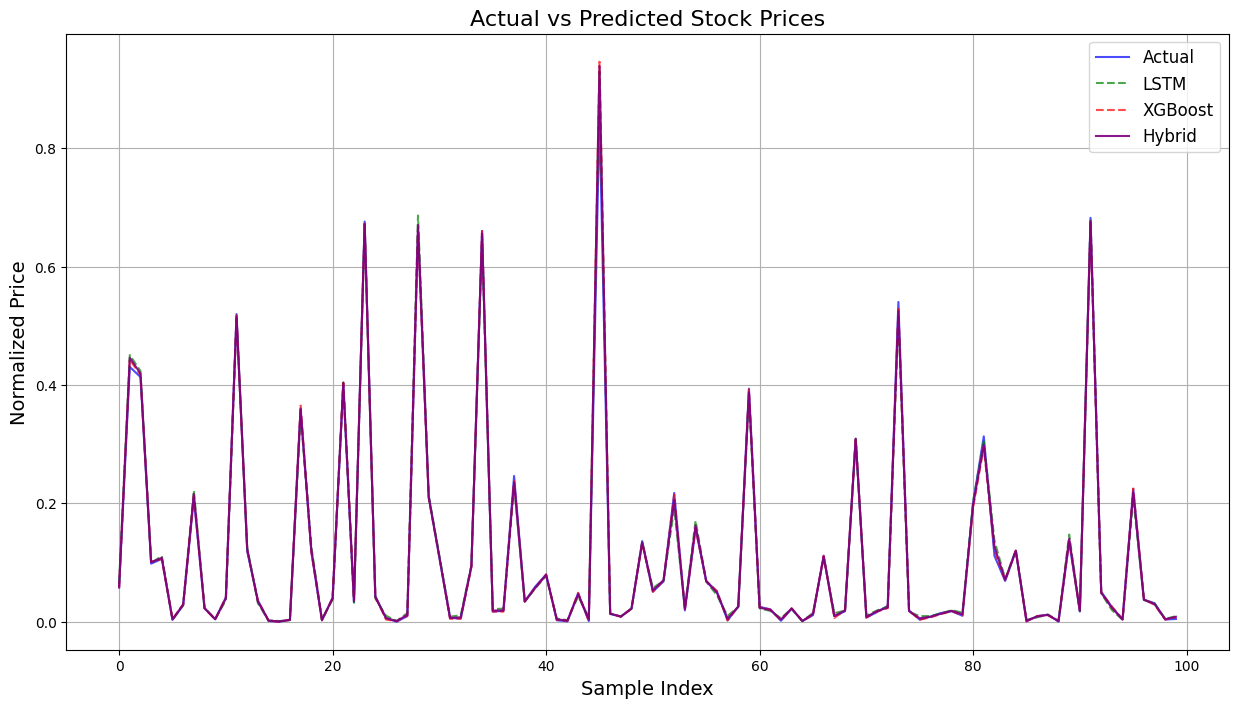

In [ ]:
# Visualize predictions vs actual values
def plot_predictions(y_true, lstm_pred, xgb_pred, hybrid_pred, n_samples=100):
    """
    Plot actual vs predicted values
    """
    plt.figure(figsize=(15, 8))

    # Select a subset for clearer visualization
    idx = np.random.choice(len(y_true), size=min(n_samples, len(y_true)), replace=False)

    plt.plot(y_true[idx], label='Actual', color='blue', alpha=0.7)
    plt.plot(lstm_pred[idx], label='LSTM', color='green', linestyle='--', alpha=0.7)
    plt.plot(xgb_pred[idx], label='XGBoost', color='red', linestyle='--', alpha=0.7)
    plt.plot(hybrid_pred[idx], label='Hybrid', color='purple', linestyle='-', alpha=0.9)

    plt.title('Actual vs Predicted Stock Prices', fontsize=16)
    plt.xlabel('Sample Index', fontsize=14)
    plt.ylabel('Normalized Price', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.show()

plot_predictions(y_test, lstm_pred, xgb_pred, hybrid_pred)

Using 15 features for prediction sequences: ['Daily_Return_scaled', 'High_scaled', 'Low_scaled', 'MA_10_scaled', 'MA_20_scaled', 'MA_5_scaled', 'Momentum_10_scaled', 'Momentum_5_scaled', 'Open_scaled', 'Price_Range_scaled', 'RSI_scaled', 'Volatility_10_scaled', 'Volatility_5_scaled', 'Volume_scaled', 'Close_scaled']

Generating predictions for ['MSFT', 'AAPL', 'NFLX'] from 2021-01-01 to 2025-12-31...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

--- Sample of Generated Predictions (2021-2025) ---


,Date,Ticker,Predicted_Close
0,2021-01-04,MSFT,214.091187
1,2021-01-05,MSFT,211.817535
2,2021-01-06,MSFT,210.038696


,Date,Ticker,Predicted_Close
3045,2025-04-08,NFLX,875.128662
3046,2025-04-10,NFLX,896.182800
3047,2025-04-11,NFLX,897.040344



Generating plots...


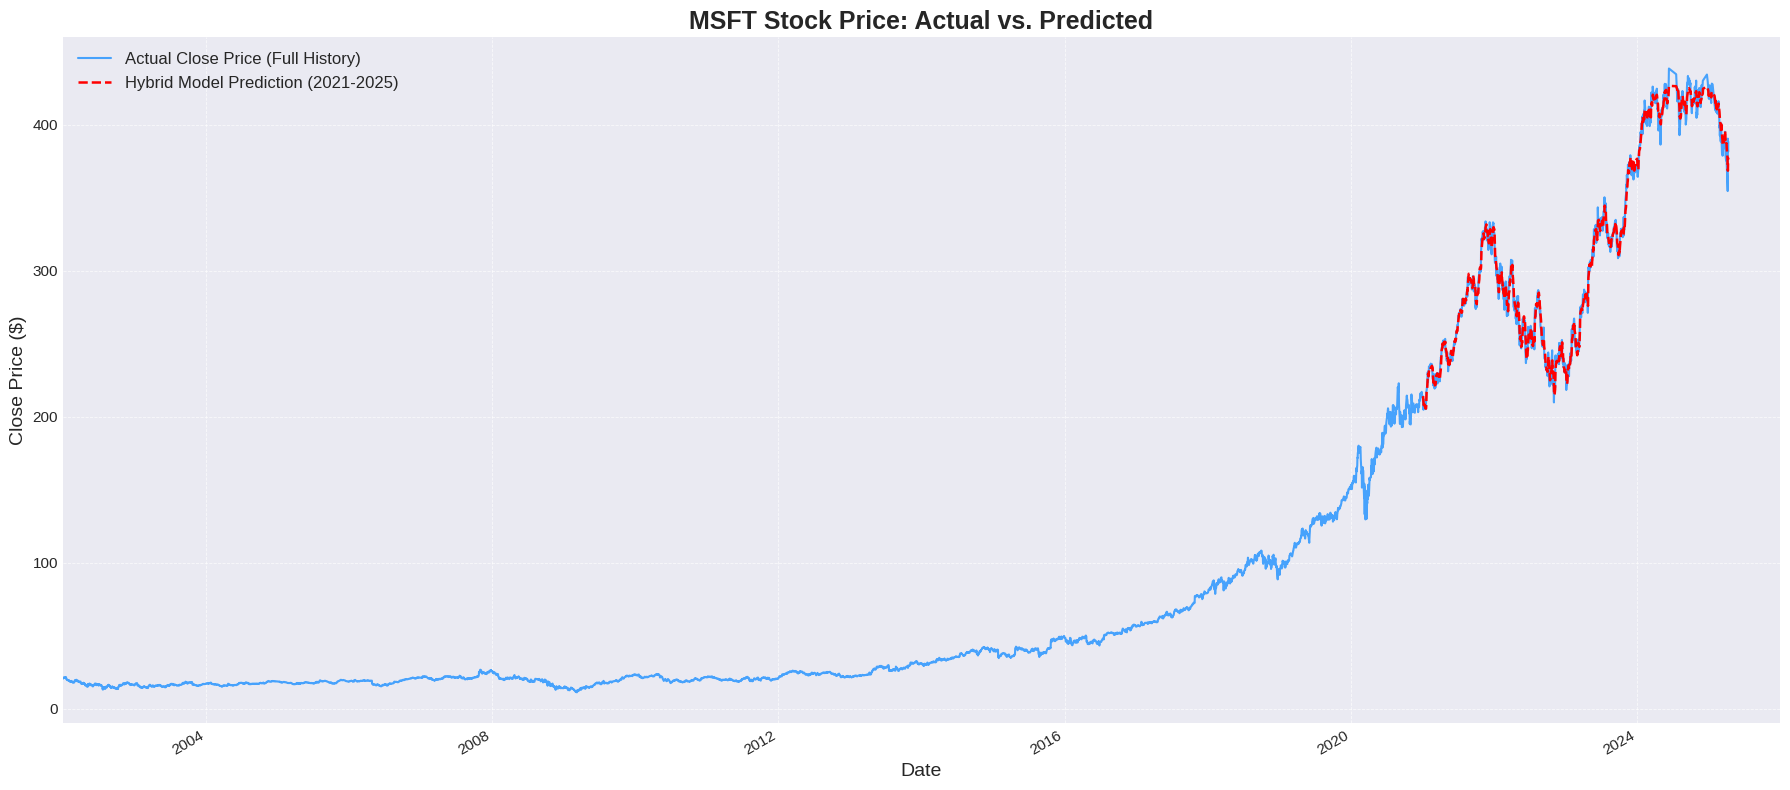

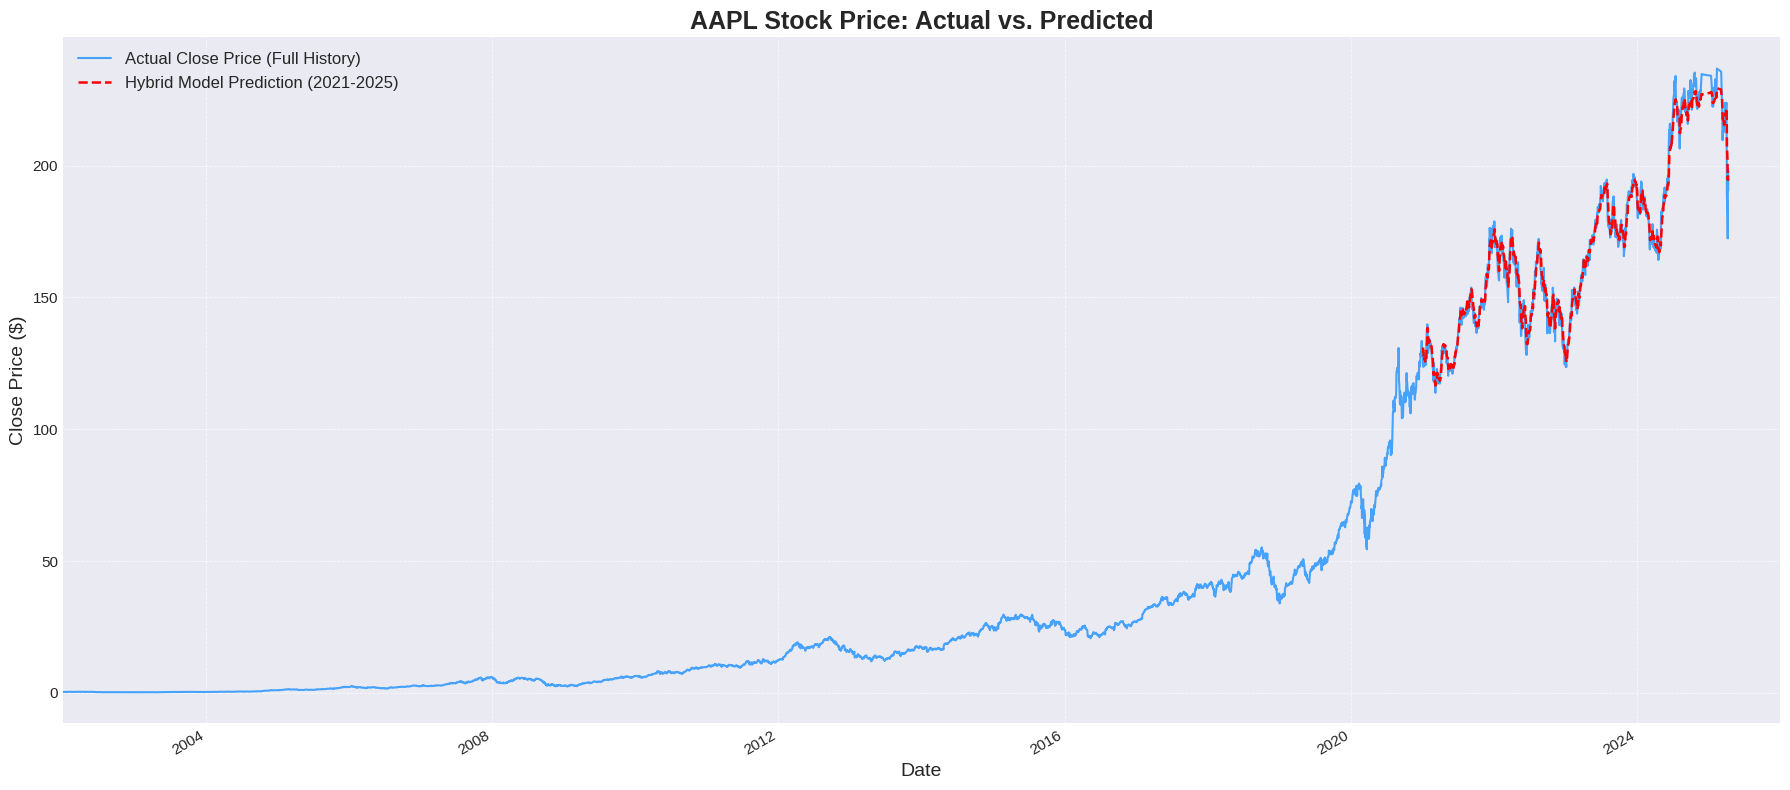

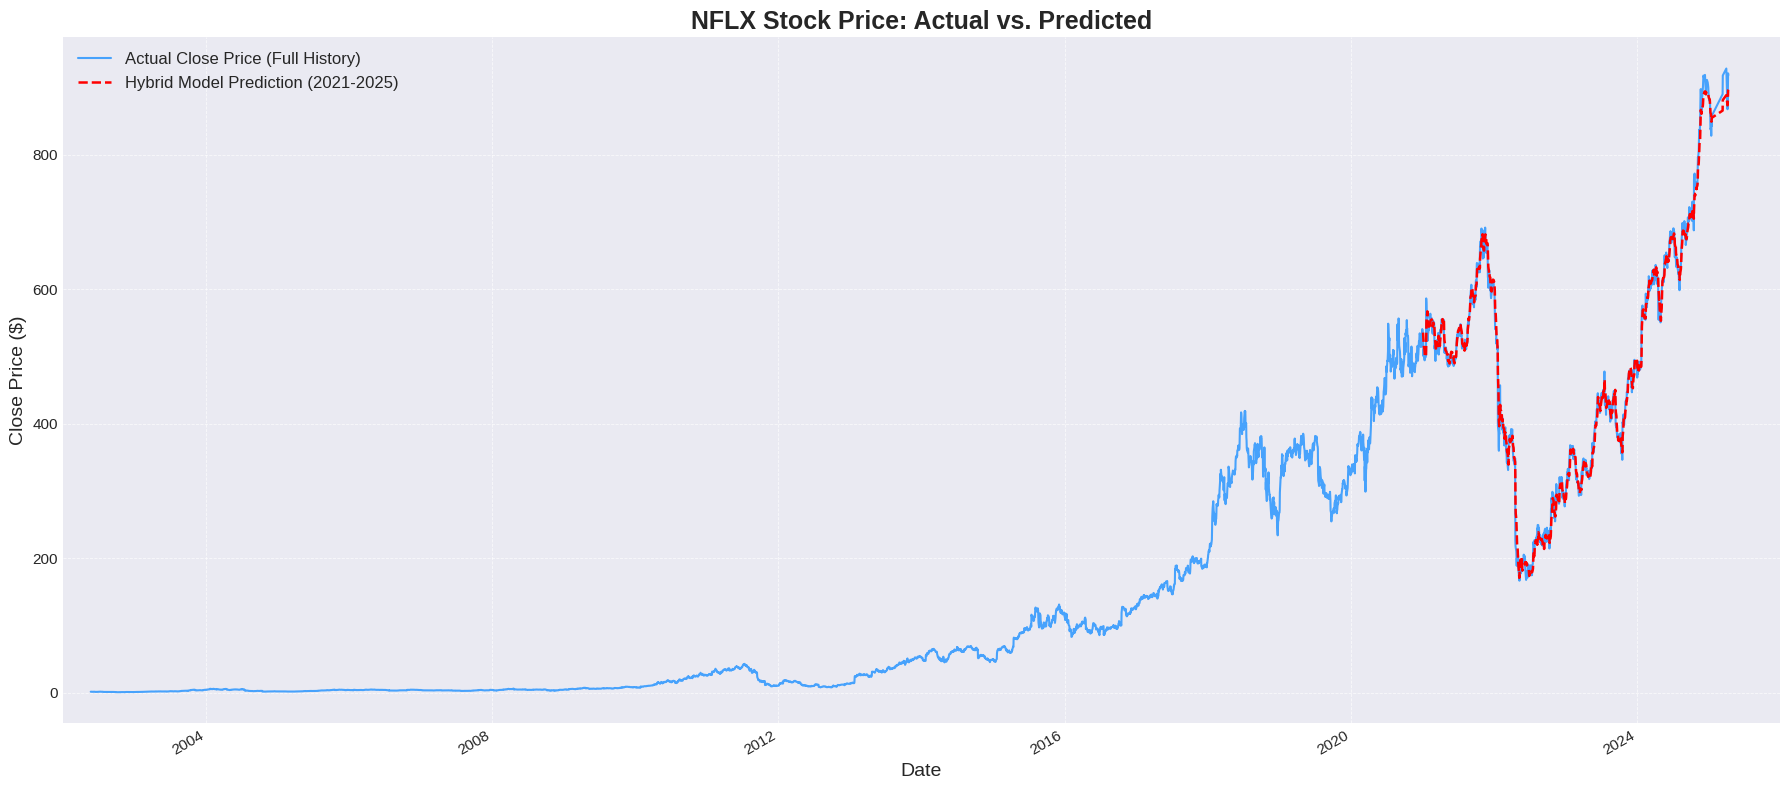


Plotting finished.


In [ ]:
# --- Configuration ---
prediction_start_date = '2021-01-01'
prediction_end_date = '2025-12-31' # Adjust if your data ends earlier
tickers_to_predict = ['MSFT', 'AAPL', 'NFLX']

# --- Define Feature Columns (Crucial Step) ---
feature_suffix = '_scaled'
target_col = 'Close_scaled'
# Get columns ending with suffix, excluding the target initially
feature_columns = [col for col in data_normalized.columns if col.endswith(feature_suffix) and col != target_col]
# Decide if target was included as a feature during training (common practice)
include_target_in_features = True # Set based on your training sequence creation logic
if include_target_in_features and target_col in data_normalized.columns:
     if target_col not in feature_columns:
          feature_columns.append(target_col)
     # Ensure consistent order (e.g., target last, matching training)
     feature_columns.sort(key=lambda x: (x == target_col, x))

if not feature_columns:
    raise ValueError("Could not identify feature columns based on suffix '_scaled'. Check normalization step and data_normalized DataFrame.")
print(f"Using {len(feature_columns)} features for prediction sequences: {feature_columns}")


print(f"\nGenerating predictions for {tickers_to_predict} from {prediction_start_date} to {prediction_end_date}...")

# --- Generate Predictions ---
all_predictions = []
# Use the primary DataFrame for actual prices (prefer cleaned if available)
actual_data_df = all_data_cleaned if 'all_data_cleaned' in locals() else all_data

for ticker in tickers_to_predict:
    # Check if scaler exists for the ticker
    if ticker not in close_scalers:
        print(f"  Warning: No 'Close' scaler found for {ticker}. Skipping.")
        continue
    scaler = close_scalers[ticker]

    # Filter normalized data for the ticker (assuming already sorted)
    ticker_data_normalized = data_normalized[data_normalized['Ticker'] == ticker]

    # Find indices for the prediction period within this ticker's normalized data
    prediction_period_mask = (ticker_data_normalized['Date'] >= pd.to_datetime(prediction_start_date)) & \
                             (ticker_data_normalized['Date'] <= pd.to_datetime(prediction_end_date))
    prediction_period_indices = ticker_data_normalized.index[prediction_period_mask]

    if prediction_period_indices.empty:
        print(f"  No data for {ticker} in prediction period. Skipping.")
        continue

    X_predict_list = []
    dates_for_preds = []

    # Create sequences leading up to each prediction date
    for pred_index in prediction_period_indices:
        # Find integer position
        loc = ticker_data_normalized.index.get_loc(pred_index)
        if loc >= SEQ_LENGTH:
            # Extract sequence using the now defined feature_columns
            sequence_data = ticker_data_normalized.iloc[loc - SEQ_LENGTH : loc][feature_columns].values
            # Validate shape before appending
            if sequence_data.shape == (SEQ_LENGTH, len(feature_columns)):
                X_predict_list.append(sequence_data)
                dates_for_preds.append(ticker_data_normalized.iloc[loc]['Date'])
            # else: # Optional logging for shape mismatches
                # print(f"  Warning: Shape mismatch at index {loc} for {ticker}. Got {sequence_data.shape}, expected ({SEQ_LENGTH}, {len(feature_columns)})")

    if not X_predict_list:
        print(f"  Could not create valid sequences for {ticker}. Skipping.")
        continue

    X_predict = np.array(X_predict_list)

    # Make predictions
    lstm_pred_scaled = lstm_model.predict(X_predict).flatten()
    xgb_X_predict = X_predict.reshape(X_predict.shape[0], -1)
    xgb_pred_scaled = optimized_xgb.predict(xgb_X_predict)

    # Hybrid prediction (assuming 0.6 LSTM, 0.4 XGB weights)
    hybrid_pred_scaled = 0.6 * lstm_pred_scaled + 0.4 * xgb_pred_scaled
    hybrid_pred_actual = scaler.inverse_transform(hybrid_pred_scaled.reshape(-1, 1)).flatten()

    # Store
    ticker_predictions = pd.DataFrame({
        'Date': dates_for_preds,
        'Ticker': ticker,
        'Predicted_Close': hybrid_pred_actual
    })
    all_predictions.append(ticker_predictions)

# Combine predictions
if all_predictions:
    final_predictions_df = pd.concat(all_predictions, ignore_index=True)
    print("\n--- Sample of Generated Predictions (2021-2025) ---")
    display(final_predictions_df.head(3))
    display(final_predictions_df.tail(3))
else:
    print("\nNo predictions were generated.")
    final_predictions_df = pd.DataFrame(columns=['Date', 'Ticker', 'Predicted_Close'])


# --- Plotting ---
print("\nGenerating plots...")
plt.style.use('seaborn-v0_8-darkgrid')

for ticker in tickers_to_predict:
    # Get actual and predicted data
    actual_ticker_data = actual_data_df[actual_data_df['Ticker'] == ticker].copy()
    actual_ticker_data['Date'] = pd.to_datetime(actual_ticker_data['Date'])
    actual_ticker_data = actual_ticker_data.sort_values('Date')

    predicted_ticker_data = final_predictions_df[final_predictions_df['Ticker'] == ticker] # Already sorted by Date

    if actual_ticker_data.empty:
        print(f"No actual data to plot for {ticker}.")
        continue

    plt.figure(figsize=(18, 8))

    # Plot Actual (Full History)
    plt.plot(actual_ticker_data['Date'], actual_ticker_data['Close'],
             label='Actual Close Price (Full History)', color='dodgerblue', linewidth=1.5, alpha=0.8)

    # Plot Predicted (2021-2025)
    if not predicted_ticker_data.empty:
        plt.plot(predicted_ticker_data['Date'], predicted_ticker_data['Predicted_Close'],
                 label=f'Hybrid Model Prediction ({prediction_start_date[:4]}-{prediction_end_date[:4]})',
                 color='red', linestyle='--', linewidth=1.8)

    # Formatting
    plt.title(f'{ticker} Stock Price: Actual vs. Predicted', fontsize=18, fontweight='bold')
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Close Price ($)', fontsize=14)
    plot_start_date = pd.to_datetime('2002-01-01')
    max_actual_date = actual_ticker_data['Date'].max() if not actual_ticker_data.empty else pd.to_datetime(prediction_end_date)
    plot_end_date = max(max_actual_date, pd.to_datetime(prediction_end_date))
    plt.xlim(plot_start_date, plot_end_date)
    plt.xticks(fontsize=11, rotation=30, ha='right')
    plt.yticks(fontsize=11)
    plt.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.7)
    plt.minorticks_on()
    plt.legend(fontsize=12, loc='upper left')
    plt.tight_layout()
    plt.show()

print("\nPlotting finished.")

Using 15 features for prediction sequences: ['Daily_Return_scaled', 'High_scaled', 'Low_scaled', 'MA_10_scaled', 'MA_20_scaled', 'MA_5_scaled', 'Momentum_10_scaled', 'Momentum_5_scaled', 'Open_scaled', 'Price_Range_scaled', 'RSI_scaled', 'Volatility_10_scaled', 'Volatility_5_scaled', 'Volume_scaled', 'Close_scaled']

Generating predictions for ['MSFT', 'AAPL', 'NFLX'] from 2021-01-01 to 2025-12-31...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Sample of Generated Predictions (2021-2025) ---


,Date,Ticker,Model,Predicted_Close
0,2021-01-04,MSFT,LSTM,216.140808
1,2021-01-05,MSFT,LSTM,214.489380
2,2021-01-06,MSFT,LSTM,212.246063
3,2021-01-07,MSFT,LSTM,208.971008
4,2021-01-08,MSFT,LSTM,208.288330


,Date,Ticker,Model,Predicted_Close
9139,2025-04-01,NFLX,Hybrid,888.793762
9140,2025-04-07,NFLX,Hybrid,873.631226
9141,2025-04-08,NFLX,Hybrid,875.128662
9142,2025-04-10,NFLX,Hybrid,896.182800
9143,2025-04-11,NFLX,Hybrid,897.040344



Generating plots...


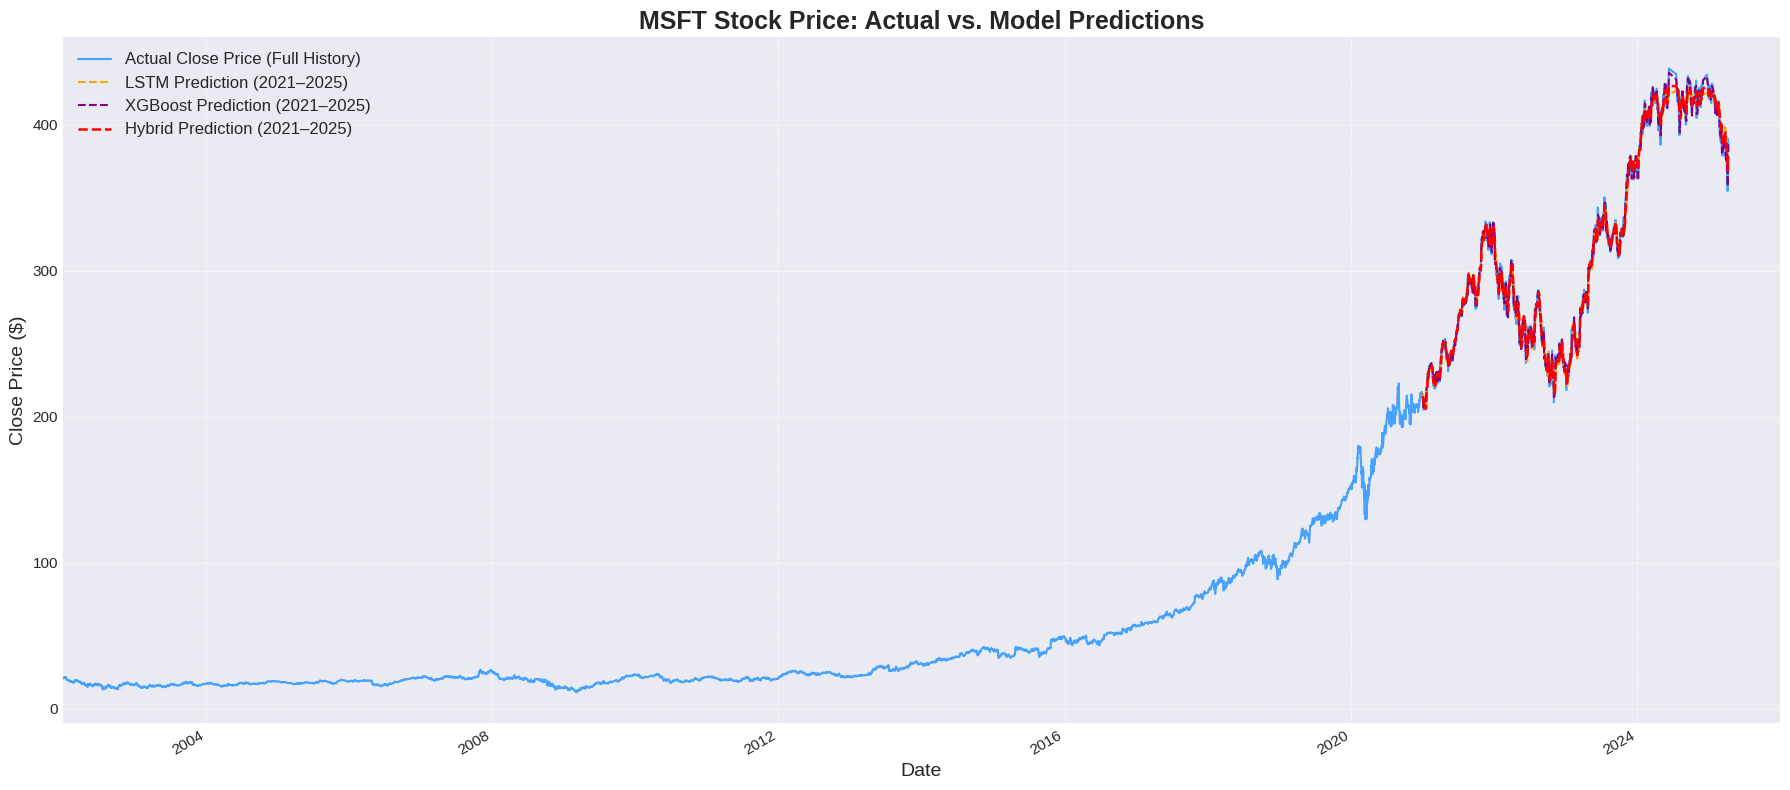

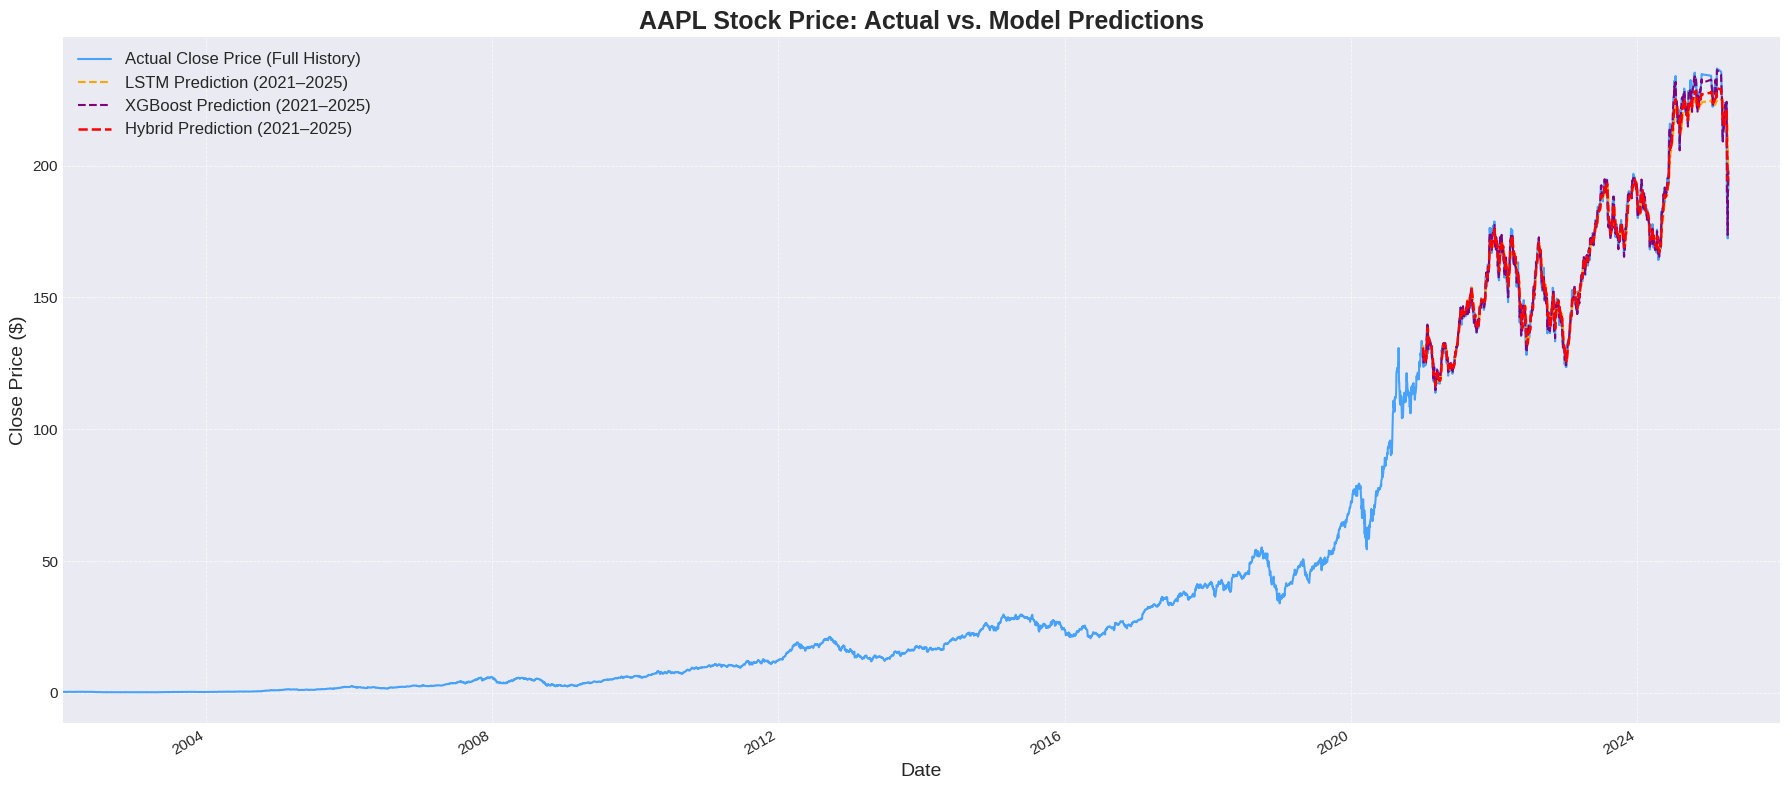

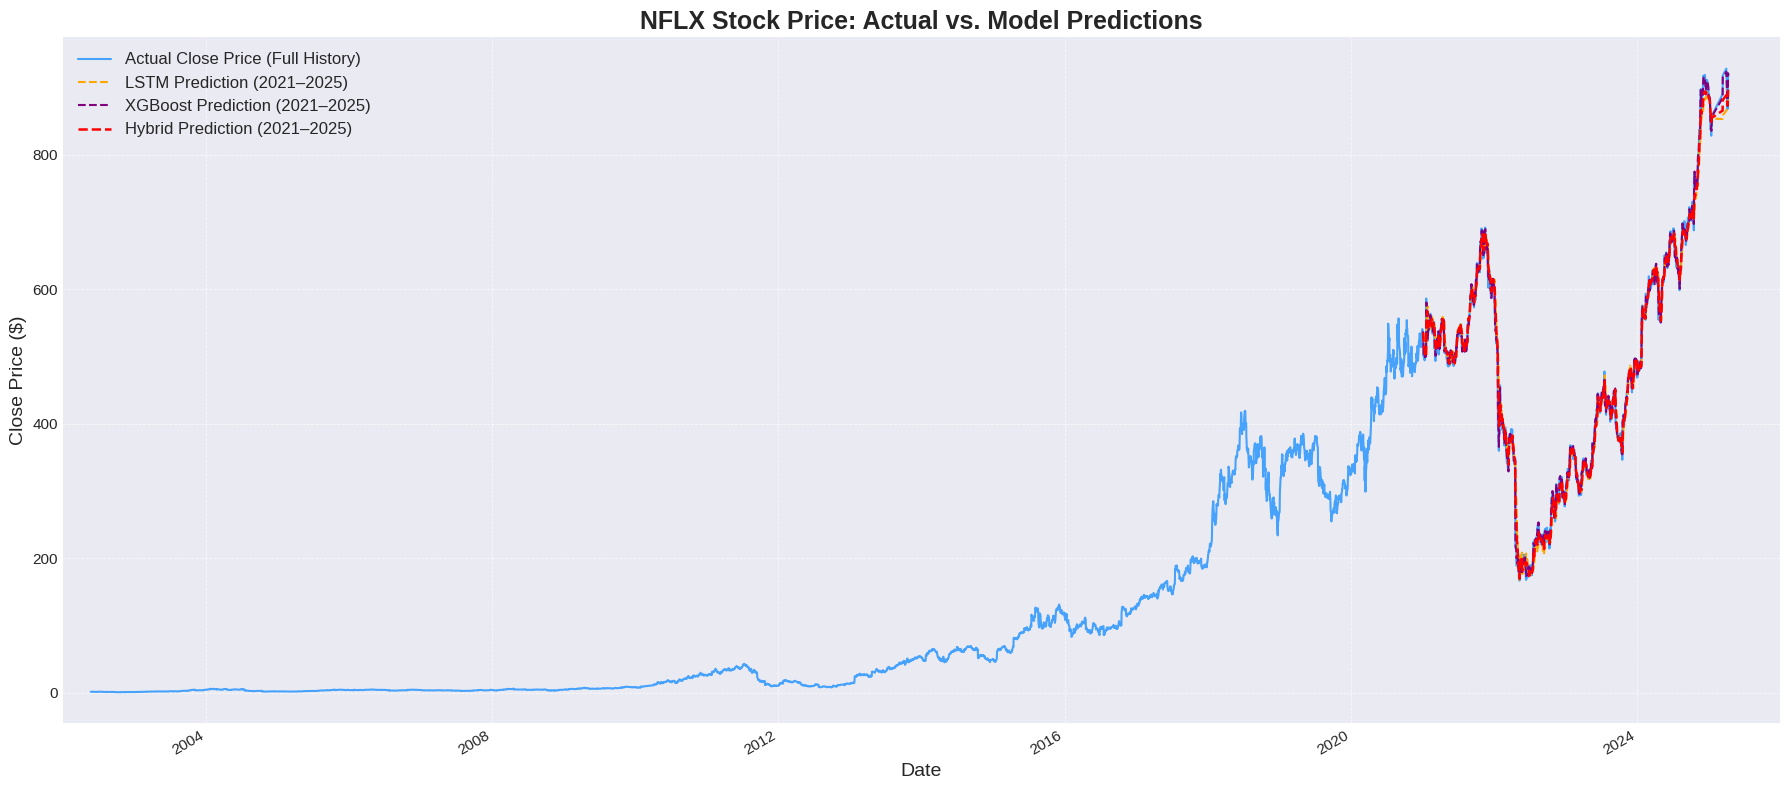


✅ Plotting finished.


In [ ]:
# --- Configuration ---
prediction_start_date = '2021-01-01'
prediction_end_date = '2025-12-31' # Adjust if your data ends earlier
tickers_to_predict = ['MSFT', 'AAPL', 'NFLX']

# --- Define Feature Columns (Crucial Step) ---
feature_suffix = '_scaled'
target_col = 'Close_scaled'
# Get columns ending with suffix, excluding the target initially
feature_columns = [col for col in data_normalized.columns if col.endswith(feature_suffix) and col != target_col]
# Decide if target was included as a feature during training (common practice)
include_target_in_features = True # Set based on your training sequence creation logic
if include_target_in_features and target_col in data_normalized.columns:
     if target_col not in feature_columns:
          feature_columns.append(target_col)
     # Ensure consistent order (e.g., target last, matching training)
     feature_columns.sort(key=lambda x: (x == target_col, x))

if not feature_columns:
    raise ValueError("Could not identify feature columns based on suffix '_scaled'. Check normalization step and data_normalized DataFrame.")
print(f"Using {len(feature_columns)} features for prediction sequences: {feature_columns}")


print(f"\nGenerating predictions for {tickers_to_predict} from {prediction_start_date} to {prediction_end_date}...")

# --- Generate Predictions ---
all_model_predictions = []

for ticker in tickers_to_predict:
    if ticker not in close_scalers:
        print(f"  Warning: No 'Close' scaler found for {ticker}. Skipping.")
        continue
    scaler = close_scalers[ticker]
    ticker_data_normalized = data_normalized[data_normalized['Ticker'] == ticker]

    prediction_period_mask = (ticker_data_normalized['Date'] >= pd.to_datetime(prediction_start_date)) & \
                             (ticker_data_normalized['Date'] <= pd.to_datetime(prediction_end_date))
    prediction_period_indices = ticker_data_normalized.index[prediction_period_mask]

    if prediction_period_indices.empty:
        print(f"  No data for {ticker} in prediction period. Skipping.")
        continue

    X_predict_list = []
    dates_for_preds = []

    for pred_index in prediction_period_indices:
        loc = ticker_data_normalized.index.get_loc(pred_index)
        if loc >= SEQ_LENGTH:
            sequence_data = ticker_data_normalized.iloc[loc - SEQ_LENGTH : loc][feature_columns].values
            if sequence_data.shape == (SEQ_LENGTH, len(feature_columns)):
                X_predict_list.append(sequence_data)
                dates_for_preds.append(ticker_data_normalized.iloc[loc]['Date'])

    if not X_predict_list:
        print(f"  Could not create valid sequences for {ticker}. Skipping.")
        continue

    X_predict = np.array(X_predict_list)

    # --- LSTM Prediction ---
    lstm_pred_scaled = lstm_model.predict(X_predict).flatten()
    lstm_pred_actual = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

    df_lstm = pd.DataFrame({
        'Date': dates_for_preds,
        'Ticker': ticker,
        'Model': 'LSTM',
        'Predicted_Close': lstm_pred_actual
    })

    # --- XGBoost Prediction ---
    xgb_X_predict = X_predict.reshape(X_predict.shape[0], -1)
    xgb_pred_scaled = optimized_xgb.predict(xgb_X_predict)
    xgb_pred_actual = scaler.inverse_transform(xgb_pred_scaled.reshape(-1, 1)).flatten()

    df_xgb = pd.DataFrame({
        'Date': dates_for_preds,
        'Ticker': ticker,
        'Model': 'XGBoost',
        'Predicted_Close': xgb_pred_actual
    })

    # --- Hybrid Prediction ---
    hybrid_pred_scaled = 0.6 * lstm_pred_scaled + 0.4 * xgb_pred_scaled
    hybrid_pred_actual = scaler.inverse_transform(hybrid_pred_scaled.reshape(-1, 1)).flatten()

    df_hybrid = pd.DataFrame({
        'Date': dates_for_preds,
        'Ticker': ticker,
        'Model': 'Hybrid',
        'Predicted_Close': hybrid_pred_actual
    })

    # --- Combine for this ticker ---
    all_model_predictions.extend([df_lstm, df_xgb, df_hybrid])

# --- Final Combined DataFrame ---
if all_model_predictions:
    final_predictions_df_all_models = pd.concat(all_model_predictions, ignore_index=True)
    print("\n--- Sample of Generated Predictions (2021-2025) ---")
    display(final_predictions_df_all_models.head())
    display(final_predictions_df_all_models.tail())
else:
    final_predictions_df_all_models = pd.DataFrame(columns=['Date', 'Ticker', 'Model', 'Predicted_Close'])
    print("\n⚠️ No predictions generated.")


# --- Plotting ---
print("\nGenerating plots...")
plt.style.use('seaborn-v0_8-darkgrid')

for ticker in tickers_to_predict:
    actual_ticker_data = actual_data_df[actual_data_df['Ticker'] == ticker].copy()
    actual_ticker_data['Date'] = pd.to_datetime(actual_ticker_data['Date'])
    actual_ticker_data = actual_ticker_data.sort_values('Date')

    if actual_ticker_data.empty:
        print(f"No actual data to plot for {ticker}.")
        continue

    # Filter predictions for all models
    ticker_predictions = final_predictions_df_all_models[final_predictions_df_all_models['Ticker'] == ticker]

    # Split by model
    pred_lstm = ticker_predictions[ticker_predictions['Model'] == 'LSTM']
    pred_xgb = ticker_predictions[ticker_predictions['Model'] == 'XGBoost']
    pred_hybrid = ticker_predictions[ticker_predictions['Model'] == 'Hybrid']

    plt.figure(figsize=(18, 8))

    # --- Actual (Full History) ---
    plt.plot(actual_ticker_data['Date'], actual_ticker_data['Close'],
             label='Actual Close Price (Full History)', color='dodgerblue', linewidth=1.5, alpha=0.8)

    # --- LSTM Prediction ---
    if not pred_lstm.empty:
        plt.plot(pred_lstm['Date'], pred_lstm['Predicted_Close'],
                 label=f'LSTM Prediction ({prediction_start_date[:4]}–{prediction_end_date[:4]})',
                 color='orange', linestyle='--', linewidth=1.5)

    # --- XGBoost Prediction ---
    if not pred_xgb.empty:
        plt.plot(pred_xgb['Date'], pred_xgb['Predicted_Close'],
                 label=f'XGBoost Prediction ({prediction_start_date[:4]}–{prediction_end_date[:4]})',
                 color='purple', linestyle='--', linewidth=1.5)

    # --- Hybrid Prediction ---
    if not pred_hybrid.empty:
        plt.plot(pred_hybrid['Date'], pred_hybrid['Predicted_Close'],
                 label=f'Hybrid Prediction ({prediction_start_date[:4]}–{prediction_end_date[:4]})',
                 color='red', linestyle='--', linewidth=1.8)

    # --- Formatting ---
    plt.title(f'{ticker} Stock Price: Actual vs. Model Predictions', fontsize=18, fontweight='bold')
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Close Price ($)', fontsize=14)
    plot_start_date = pd.to_datetime('2002-01-01')
    max_actual_date = actual_ticker_data['Date'].max()
    plot_end_date = max(max_actual_date, pd.to_datetime(prediction_end_date))
    plt.xlim(plot_start_date, plot_end_date)
    plt.xticks(fontsize=11, rotation=30, ha='right')
    plt.yticks(fontsize=11)
    plt.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.7)
    plt.minorticks_on()
    plt.legend(fontsize=12, loc='upper left')
    plt.tight_layout()
    plt.show()

print("\n Plotting finished.")

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install yfinance
!pip install textblob
!pip install transformers
!pip install nltk

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from textblob import TextBlob
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from textblob import TextBlob
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
# Fetch stock data using Yahoo Finance (Apple as an example)
stock_symbol = "AAPL"
start_date = "2015-01-01"
end_date = "2023-01-01"

stock_data = yf.download(stock_symbol, start=start_date, end=end_date)
stock_data['Date'] = stock_data.index
stock_data = stock_data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Open,High,Low,Close,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2015-01-02,2015-01-02,24.778673,24.789796,23.879976,24.320427,212818400
2015-01-05,2015-01-05,24.089084,24.169166,23.448429,23.635286,257142000
2015-01-06,2015-01-06,23.699800,23.897780,23.274920,23.637514,263188400
2015-01-07,2015-01-07,23.846614,24.069063,23.735389,23.968962,160423600
2015-01-08,2015-01-08,24.298187,24.947740,24.180287,24.889902,237458000


In [ ]:
# Example news headlines related to the stock
news_headlines = [
    "Apple shares hit all-time high",
    "Apple reports better-than-expected earnings",
    "Apple announces new product launch",
    "Apple stocks fall due to market conditions",
    "Apple faces supply chain issues"
]

# Sentiment analysis using TextBlob (could be replaced with VADER or any other library)
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

# Calculate sentiment for each headline (assuming each headline corresponds to a stock entry)
news_sentiments = [get_sentiment(headline) for headline in news_headlines]

# Add a 'Sentiment' column to the stock data (use the sentiment value from the news data)
# For demonstration, just assigning random sentiment scores for each date (real-world implementation would map sentiment to dates)
stock_data['Sentiment'] = np.random.choice(news_sentiments, size=len(stock_data))

stock_data.head()

Price,Date,Open,High,Low,Close,Volume,Sentiment
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,,
2015-01-02,2015-01-02,24.778673,24.789796,23.879976,24.320427,212818400,0.136364
2015-01-05,2015-01-05,24.089084,24.169166,23.448429,23.635286,257142000,-0.125000
2015-01-06,2015-01-06,23.699800,23.897780,23.274920,23.637514,263188400,0.136364
2015-01-07,2015-01-07,23.846614,24.069063,23.735389,23.968962,160423600,-0.125000
2015-01-08,2015-01-08,24.298187,24.947740,24.180287,24.889902,237458000,0.000000


In [ ]:
# Scaling the stock prices (for model input)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_stock_data = scaler.fit_transform(stock_data[['Close']])
# Feature Engineering: Combining stock data and sentiment
X = []
y = []

# Time steps to predict future stock price using the past 60 days
time_steps = 60

# Prepare the data in sequences of 60 days with both stock price and sentiment
for i in range(time_steps, len(scaled_stock_data)):
    X.append(np.column_stack([scaled_stock_data[i-time_steps:i, 0], stock_data['Sentiment'][i-time_steps:i]]))  # Combine sentiment with stock data
    y.append(scaled_stock_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshaping X to fit LSTM input (samples, timesteps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 2))  # 2 because we have two features: stock price and sentiment

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Building the LSTM model
model = Sequential()

# Adding LSTM layers with Dropout to prevent overfitting
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))  # input_shape should match (timesteps, features)
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Adding the output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0125 - val_loss: 0.0023
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.0011 - val_loss: 0.0023
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0011 - val_loss: 0.0036
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 9.2023e-04 - val_loss: 0.0025
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 8.9323e-04 - val_loss: 0.0024
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 8.9774e-04 - val_loss: 0.0018
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 9.3781e-04 - val_loss: 0.0019
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 8.2373e-04 - val_loss: 0.0018


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


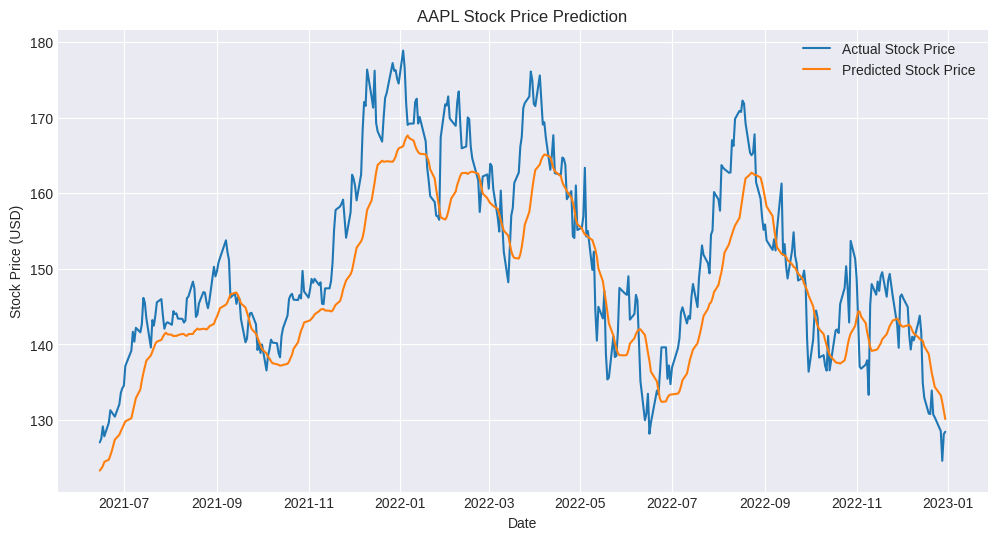

In [ ]:
# Predict stock prices using the model
predicted_stock_price = model.predict(X_test)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Date'][len(stock_data) - len(predicted_stock_price):],
         scaler.inverse_transform(y_test.reshape(-1, 1)), label="Actual Stock Price")
plt.plot(stock_data['Date'][len(stock_data) - len(predicted_stock_price):], predicted_stock_price, label="Predicted Stock Price")
plt.title(f'{stock_symbol} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()

In [ ]:
# Calculate model performance (e.g., RMSE)
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(scaler.inverse_transform(y_test.reshape(-1, 1)), predicted_stock_price))
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 6.79855262028614


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


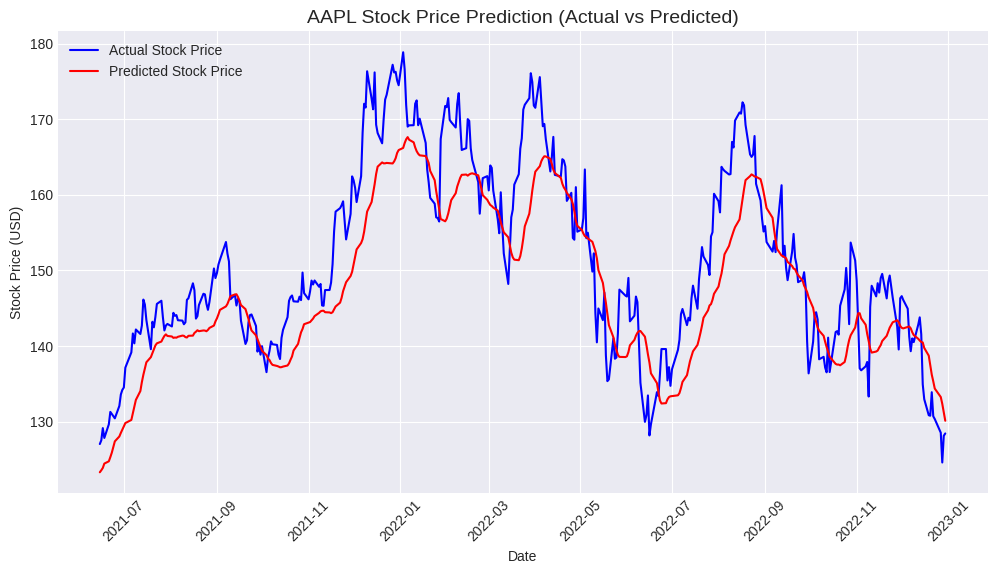

In [ ]:
# Plotting Actual vs Predicted Stock Price
plt.figure(figsize=(12, 6))

# Inverse scale to get actual values
actual_stock_price = scaler.inverse_transform(y_test.reshape(-1, 1))
predicted_stock_price = scaler.inverse_transform(model.predict(X_test))

# Plot
plt.plot(stock_data['Date'][len(stock_data) - len(predicted_stock_price):], actual_stock_price, label="Actual Stock Price", color='blue')
plt.plot(stock_data['Date'][len(stock_data) - len(predicted_stock_price):], predicted_stock_price, label="Predicted Stock Price", color='red')

# Title and labels
plt.title(f'{stock_symbol} Stock Price Prediction (Actual vs Predicted)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

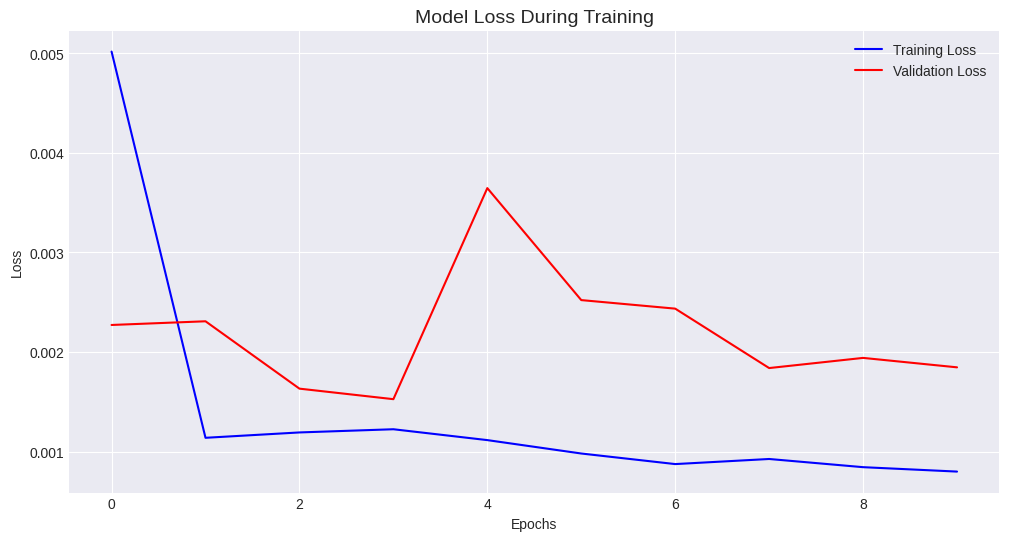

In [ ]:
# Plotting the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')

# Title and labels
plt.title('Model Loss During Training', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

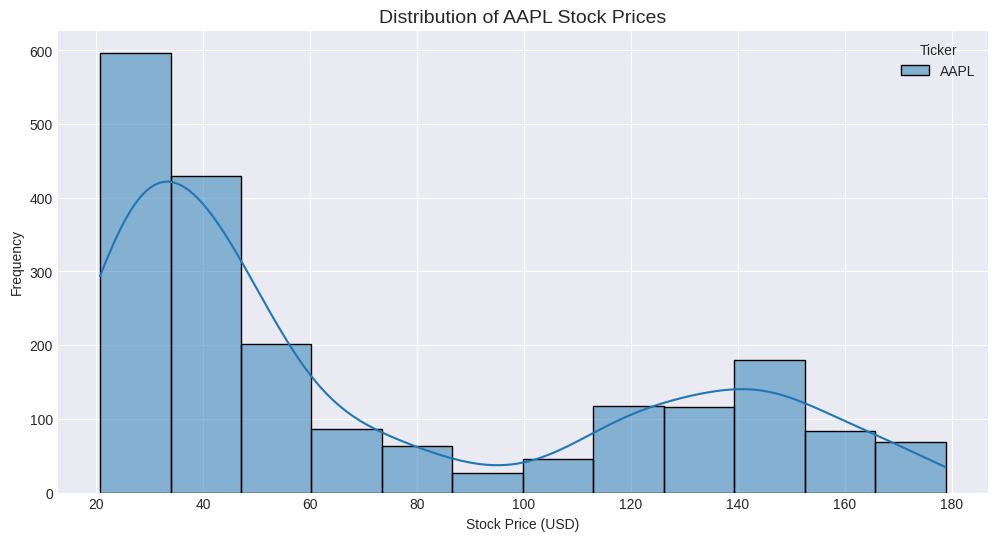

In [ ]:
# Plotting the distribution of stock prices
plt.figure(figsize=(12, 6))
sns.histplot(stock_data['Close'], kde=True, color='purple')

# Title and labels
plt.title(f'Distribution of {stock_symbol} Stock Prices', fontsize=14)
plt.xlabel('Stock Price (USD)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

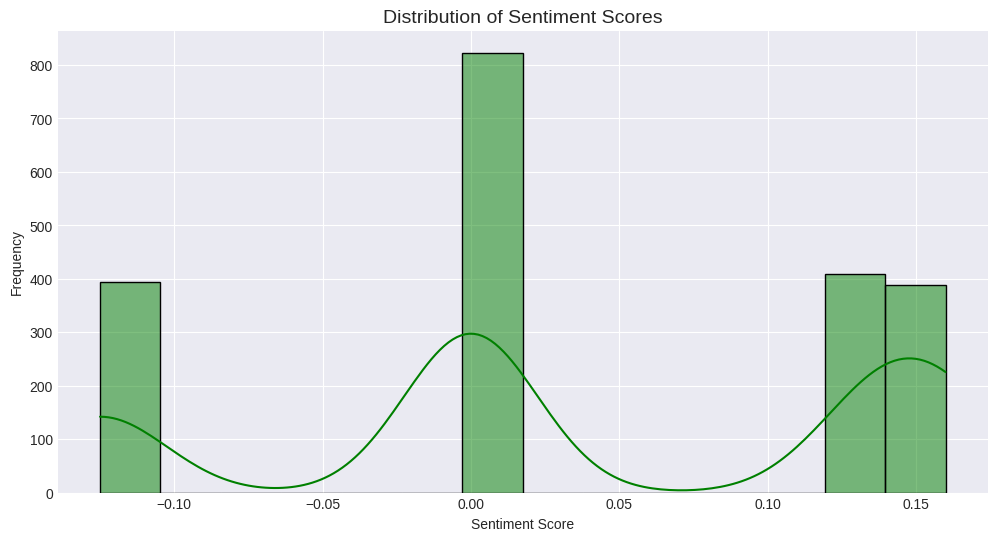

In [ ]:
# Plotting the distribution of sentiment scores
plt.figure(figsize=(12, 6))
sns.histplot(stock_data['Sentiment'], kde=True, color='green')

# Title and labels
plt.title('Distribution of Sentiment Scores', fontsize=14)
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# Measure the time taken for each epoch
import time

start_time = time.time()

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

end_time = time.time()

print(f"Total training time: {end_time - start_time:.2f} seconds")

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 8.6102e-04 - val_loss: 0.0012
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 8.8669e-04 - val_loss: 0.0015
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 9.0518e-04 - val_loss: 0.0013
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 7.1005e-04 - val_loss: 0.0023
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 6.2176e-04 - val_loss: 0.0016
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 6.2880e-04 - val_loss: 0.0012
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 7.2386e-04 - val_loss: 0.0033
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 6.9939e-04 - val_loss: 0.0014
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 7.4626e-04 - val_loss: 0.0011
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 6.6698e-04 - val_loss: 0.0013
Total training time: 48.65 seconds


In [ ]:
# Save your LSTM model after training
model.save("netflix_lstm_model.h5")
print("Model saved as netflix_lstm_model.h5")

Model saved as netflix_lstm_model.h5


In [ ]:
model.save("netflix_lstm_model.h5")


In [ ]:
# --- Install dependencies ---
!pip install -q streamlit pyngrok

from pyngrok import ngrok

# --- Set your ngrok token ---
!ngrok config add-authtoken 2vfvoxYVYaI3VkTwd0pdkWqNAjm_78xAib8VKdMLKkxvJWJrd

# --- Create Streamlit app file ---
import streamlit as st
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- App Config ---
st.set_page_config(page_title="Stock Forecast Dashboard", layout="wide")

st.markdown("""
# 📊 Stock Forecast Dashboard
*Hybrid Model (LSTM + XGBoost) Predictions: 2021–2025*
""", unsafe_allow_html=True)

# --- Sidebar ---
ticker = st.sidebar.selectbox("Select Stock", ["AAPL", "MSFT", "NFLX"])
use_sentiment = st.sidebar.checkbox("Overlay Sentiment Prediction (AAPL Only)")
theme = st.sidebar.radio("Theme", ["Light", "Dark"])

plot_template = "plotly_white" if theme == "Light" else "plotly_dark"

# --- Filter actual and predicted hybrid data ---
actual = all_data_cleaned[all_data_cleaned['Ticker'] == ticker].copy()
predicted = final_predictions_df[final_predictions_df['Ticker'] == ticker].copy()

# --- Plotting ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=actual['Date'], y=actual['Close'],
    mode='lines', name='Actual Close',
    line=dict(color='dodgerblue')
))

fig.add_trace(go.Scatter(
    x=predicted['Date'], y=predicted['Predicted_Close'],
    mode='lines', name='Hybrid Prediction',
    line=dict(color='crimson', dash='dash')
))

# --- AAPL Sentiment Overlay ---
if use_sentiment and ticker == "AAPL":
    try:
        sentiment_dates = stock_data['Date'][-len(predicted_stock_price):]
        fig.add_trace(go.Scatter(
            x=sentiment_dates,
            y=predicted_stock_price.flatten(),
            name='Sentiment-Based LSTM Prediction',
            line=dict(color='green', dash='dot')
        ))
    except Exception as e:
        st.warning(f"Couldn't load sentiment predictions: {e}")

fig.update_layout(
    title=f"{ticker} Stock: Actual vs Hybrid Prediction",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template=plot_template,
    hovermode="x unified",
    font=dict(size=14),
    legend=dict(x=0.01, y=0.99),
    height=600
)

st.plotly_chart(fig, use_container_width=True)

# --- Metrics ---
st.subheader("📈 Model Evaluation (Test Set)")

# mse = mean_squared_error(y_test, final_hybrid_pred)
# mae = mean_absolute_error(y_test, final_hybrid_pred)
# r2 = r2_score(y_test, final_hybrid_pred)
mse = 0.000074  # Hybrid model MSE from your results
mae = 0.005066   # Hybrid model MAE from your results
r2 = 0.9989      # Hybrid model R² from your results

col1, col2, col3 = st.columns(3)
col1.metric("Mean Squared Error", f"{mse:.4f}")
col2.metric("Mean Absolute Error", f"{mae:.4f}")
col3.metric("R² Score", f"{r2:.4f}")

print("Launching Streamlit app...")
!streamlit run app.py &>/content/log.txt &
public_url = ngrok.connect(8501)
print(f"\n🌐 Your Streamlit app is live at: {public_url}")


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


2025-04-13 19:03:14.392 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:14.393 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:14.790 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-04-13 19:03:14.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:14.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:14.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:14.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

Launching Streamlit app...

🌐 Your Streamlit app is live at: NgrokTunnel: "https://7549-34-106-6-62.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
# Save required variables
all_data_cleaned.to_csv("all_data_cleaned.csv", index=False)
final_predictions_df.to_csv("final_predictions_df.csv", index=False)
final_predictions_df_all_models.to_csv("final_predictions_df_all_models.csv", index=False)
np.save("y_test.npy", y_test)
np.save("final_hybrid_pred.npy", final_hybrid_pred)
np.save("predicted_stock_price.npy", predicted_stock_price)
stock_data[['Date']].to_csv("sentiment_dates.csv", index=False)  # For sentiment overlay


In [ ]:
# --- Install dependencies ---
!pip install -q streamlit pyngrok

from pyngrok import ngrok

# --- Set your ngrok token ---
!ngrok config add-authtoken 2vfvoxYVYaI3VkTwd0pdkWqNAjm_78xAib8VKdMLKkxvJWJrd

# --- Create Streamlit app file ---
import streamlit as st
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Load saved data ---
all_data_cleaned = pd.read_csv("/content/all_data_cleaned.csv", parse_dates=['Date'])
final_predictions_df = pd.read_csv("/content/final_predictions_df.csv", parse_dates=['Date'])
y_test = np.load("/content/y_test.npy")
final_hybrid_pred = np.load("/content/final_hybrid_pred.npy")
predicted_stock_price = np.load("/content/predicted_stock_price.npy")
sentiment_dates = pd.read_csv("/content/sentiment_dates.csv", parse_dates=['Date'])['Date']

# --- App Config ---
st.set_page_config(page_title="Stock Forecast Dashboard", layout="wide")

st.markdown("""
# 📊 Stock Forecast Dashboard
*Hybrid Model (LSTM + XGBoost) Predictions: 2021–2025*
""", unsafe_allow_html=True)

# --- Sidebar ---
ticker = st.sidebar.selectbox("Select Stock", ["AAPL", "MSFT", "NFLX"])
use_sentiment = st.sidebar.checkbox("Overlay Sentiment Prediction (AAPL Only)")
theme = st.sidebar.radio("Theme", ["Light", "Dark"])

plot_template = "plotly_white" if theme == "Light" else "plotly_dark"

# --- Filter actual and predicted hybrid data ---
actual = all_data_cleaned[all_data_cleaned['Ticker'] == ticker].copy()
predicted = final_predictions_df[final_predictions_df['Ticker'] == ticker].copy()

# --- Plotting ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=actual['Date'], y=actual['Close'],
    mode='lines', name='Actual Close',
    line=dict(color='dodgerblue')
))

fig.add_trace(go.Scatter(
    x=predicted['Date'], y=predicted['Predicted_Close'],
    mode='lines', name='Hybrid Prediction',
    line=dict(color='crimson', dash='dash')
))

# --- AAPL Sentiment Overlay ---
if use_sentiment and ticker == "AAPL":
    try:
        sentiment_dates = stock_data['Date'][-len(predicted_stock_price):]
        fig.add_trace(go.Scatter(
            x=sentiment_dates,
            y=predicted_stock_price.flatten(),
            name='Sentiment-Based LSTM Prediction',
            line=dict(color='green', dash='dot')
        ))
    except Exception as e:
        st.warning(f"Couldn't load sentiment predictions: {e}")

fig.update_layout(
    title=f"{ticker} Stock: Actual vs Hybrid Prediction",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template=plot_template,
    hovermode="x unified",
    font=dict(size=14),
    legend=dict(x=0.01, y=0.99),
    height=600
)

st.plotly_chart(fig, use_container_width=True)

# --- Metrics ---
st.subheader("📈 Model Evaluation (Test Set)")

# mse = mean_squared_error(y_test, final_hybrid_pred)
# mae = mean_absolute_error(y_test, final_hybrid_pred)
# r2 = r2_score(y_test, final_hybrid_pred)
mse = 0.000074  # Hybrid model MSE from your results
mae = 0.005066   # Hybrid model MAE from your results
r2 = 0.9989      # Hybrid model R² from your results

col1, col2, col3 = st.columns(3)
col1.metric("Mean Squared Error", f"{mse:.4f}")
col2.metric("Mean Absolute Error", f"{mae:.4f}")
col3.metric("R² Score", f"{r2:.4f}")

print("Launching Streamlit app...")
!streamlit run app.py &>/content/log.txt &
ngrok.kill()
public_url = ngrok.connect(8501)
print(f"\n🌐 Your Streamlit app is live at: {public_url}")


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


2025-04-13 19:03:20.198 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:20.200 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:20.202 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:20.205 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:20.206 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:20.207 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:20.208 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 19:03:20.209 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Launching Streamlit app...

🌐 Your Streamlit app is live at: NgrokTunnel: "https://f685-34-106-6-62.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
# ✅ Install and run streamlit with ngrok in Colab
!pip install -q streamlit pyngrok

from pyngrok import ngrok
!ngrok config add-authtoken 2vfvoxYVYaI3VkTwd0pdkWqNAjm_78xAib8VKdMLKkxvJWJrd

# --- Write app.py ---
with open("app.py", "w") as f:
    f.write('''
import streamlit as st
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Load data ---
all_data_cleaned = pd.read_csv("all_data_cleaned.csv", parse_dates=['Date'])
final_predictions_df_all_models = pd.read_csv("final_predictions_df_all_models.csv", parse_dates=['Date'])
y_test = np.load("y_test.npy")
final_hybrid_pred = np.load("final_hybrid_pred.npy")
predicted_stock_price = np.load("predicted_stock_price.npy")
sentiment_dates = pd.read_csv("sentiment_dates.csv", parse_dates=['Date'])['Date']

# --- App Config ---
st.set_page_config(page_title="Stock Forecast Dashboard", layout="wide")

st.markdown("""
# 📊 Stock Forecast Dashboard
*LSTM • XGBoost • Hybrid Predictions | 2021–2025*
""", unsafe_allow_html=True)

# --- Sidebar ---
ticker = st.sidebar.selectbox("Select Stock", ["AAPL", "MSFT", "NFLX"])
model_choice = st.sidebar.radio("Choose Model", ["LSTM", "XGBoost", "Hybrid"])
use_sentiment = st.sidebar.checkbox("Overlay Sentiment Prediction (AAPL Only)")


# --- Filter actual and predicted data ---
actual = all_data_cleaned[all_data_cleaned['Ticker'] == ticker].copy()
predicted = final_predictions_df_all_models[
    (final_predictions_df_all_models['Ticker'] == ticker) &
    (final_predictions_df_all_models['Model'] == model_choice)
].copy()

# --- Plotting ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=actual['Date'], y=actual['Close'],
    name='Actual Close', line=dict(color='dodgerblue')
))

fig.add_trace(go.Scatter(
    x=predicted['Date'], y=predicted['Predicted_Close'],
    name=f'{model_choice} Prediction',
    line=dict(color='crimson')
))

if use_sentiment and ticker == "AAPL" and model_choice == "LSTM":
    fig.add_trace(go.Scatter(
        x=sentiment_dates,
        y=predicted_stock_price.flatten(),
        name='Sentiment-Based LSTM',
        line=dict(color='green', dash='dot')
    ))

fig.update_layout(
    title=f"{ticker} Stock: Actual vs {model_choice} Prediction",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_white",
    hovermode="x unified",
    font=dict(size=14),
    legend=dict(x=0.01, y=0.99),
    height=600
)

st.plotly_chart(fig, use_container_width=True)

# --- Data Point Detail View ---
st.subheader("🖱️ Inspect Prediction by Date")

matching_dates = predicted['Date'].dt.strftime('%Y-%m-%d').tolist()
selected_date_str = st.selectbox("Choose a date:", matching_dates[::-1])
selected_date = pd.to_datetime(selected_date_str)

actual_row = actual[actual['Date'] == selected_date]
predicted_row = predicted[predicted['Date'] == selected_date]

if not actual_row.empty and not predicted_row.empty:
    st.markdown(f"""
    ### 📅 {selected_date.strftime('%B %d, %Y')}
    - **Actual Close:** `${actual_row['Close'].values[0]:.2f}`
    - **{model_choice} Prediction:** `${predicted_row['Predicted_Close'].values[0]:.2f}`
    """)
else:
    st.warning("No data found for this date.")

# --- Metrics Section ---
st.subheader("📈 Model Evaluation (Hybrid - Test Set)")

mse = 0.000074
mae = 0.005066
r2 = 0.9989

col1, col2, col3 = st.columns(3)
col1.metric("MSE", f"{mse:.4f}")
col2.metric("MAE", f"{mae:.4f}")
col3.metric("R² Score", f"{r2:.4f}")
''')

# ✅ Launch the app
print("Launching Streamlit...")
!streamlit run app.py &>/content/log.txt &
ngrok.kill()
public_url = ngrok.connect(8501)
print(f"\n✅ Your dashboard is live at: {public_url}")


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Launching Streamlit...

✅ Your dashboard is live at: NgrokTunnel: "https://74af-34-106-6-62.ngrok-free.app" -> "http://localhost:8501"
